<a href="https://www.kaggle.com/code/lalit7881/movies-dataset-movies-45k-films-revenue-eda-83-27?scriptVersionId=348681802" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sibamsamanta07/movies-dataset-45k-films-with-budget-and-revenue/movies_metadata.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/sibamsamanta07/movies-dataset-45k-films-with-budget-and-revenue/movies_metadata.csv")

In [3]:
df.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [4]:
df.tail()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
45461,False,NaN,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10751, 'n...",http://www.imdb.com/title/tt6209470/,439050,tt6209470,fa,رگ خواب,Rising and falling between a man and woman.,...,NaN,0.0,90.0,"[{'iso_639_1': 'fa', 'name': 'فارسی'}]",Released,Rising and falling between a man and woman,Subdue,False,4.0,1.0
45462,False,NaN,0,"[{'id': 18, 'name': 'Drama'}]",NaN,111109,tt2028550,tl,Siglo ng Pagluluwal,An artist struggles to finish his work while a...,...,2011-11-17,0.0,360.0,"[{'iso_639_1': 'tl', 'name': ''}]",Released,NaN,Century of Birthing,False,9.0,3.0
45463,False,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 18, 'nam...",NaN,67758,tt0303758,en,Betrayal,"When one of her hits goes wrong, a professiona...",...,2003-08-01,0.0,90.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,A deadly game of wits.,Betrayal,False,3.8,6.0
45464,False,NaN,0,[],NaN,227506,tt0008536,en,Satana likuyushchiy,"In a small town live two brothers, one a minis...",...,1917-10-21,0.0,87.0,[],Released,NaN,Satan Triumphant,False,0.0,0.0
45465,False,NaN,0,[],NaN,461257,tt6980792,en,Queerama,50 years after decriminalisation of homosexual...,...,2017-06-09,0.0,75.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Queerama,False,0.0,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

In [6]:
df.describe()

,revenue,runtime,vote_average,vote_count
count,4.546000e+04,45203.000000,45460.000000,45460.000000
mean,1.120935e+07,94.128199,5.618207,109.897338
std,6.433225e+07,38.407810,1.924216,491.310374
min,0.000000e+00,0.000000,0.000000,0.000000
25%,0.000000e+00,85.000000,5.000000,3.000000
50%,0.000000e+00,95.000000,6.000000,10.000000
75%,0.000000e+00,107.000000,6.800000,34.000000
max,2.787965e+09,1256.000000,10.000000,14075.000000


In [7]:
df.isnull().sum()

adult                        0
belongs_to_collection    40972
budget                       0
genres                       0
homepage                 37684
id                           0
imdb_id                     17
original_language           11
original_title               0
overview                   954
popularity                   5
poster_path                386
production_companies         3
production_countries         3
release_date                87
revenue                      6
runtime                    263
spoken_languages             6
status                      87
tagline                  25054
title                        6
video                        6
vote_average                 6
vote_count                   6
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(13)

In [9]:
df.dtypes

adult                     object
belongs_to_collection     object
budget                    object
genres                    object
homepage                  object
id                        object
imdb_id                   object
original_language         object
original_title            object
overview                  object
popularity                object
poster_path               object
production_companies      object
production_countries      object
release_date              object
revenue                  float64
runtime                  float64
spoken_languages          object
status                    object
tagline                   object
title                     object
video                     object
vote_average             float64
vote_count               float64
dtype: object

In [10]:
df.shape

(45466, 24)

In [11]:
df.columns

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count'],
      dtype='object')

In [12]:
df.nunique()

adult                        5
belongs_to_collection     1698
budget                    1226
genres                    4069
homepage                  7673
id                       45436
imdb_id                  45417
original_language           92
original_title           43373
overview                 44307
popularity               44176
poster_path              45024
production_companies     22708
production_countries      2393
release_date             17336
revenue                   6863
runtime                    353
spoken_languages          1931
status                       6
tagline                  20283
title                    42277
video                        2
vote_average                92
vote_count                1820
dtype: int64

## EDA

Dataset Shape: (45466, 24)

Columns:
['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'video', 'vote_average', 'vote_count']

DATA TYPES
adult                     object
belongs_to_collection     object
budget                    object
genres                    object
homepage                  object
id                        object
imdb_id                   object
original_language         object
original_title            object
overview                  object
popularity                object
poster_path               object
production_companies      object
production_countries      object
release_date              object
revenue                  float64
runtime                  float64
spoken_languages          object
status            

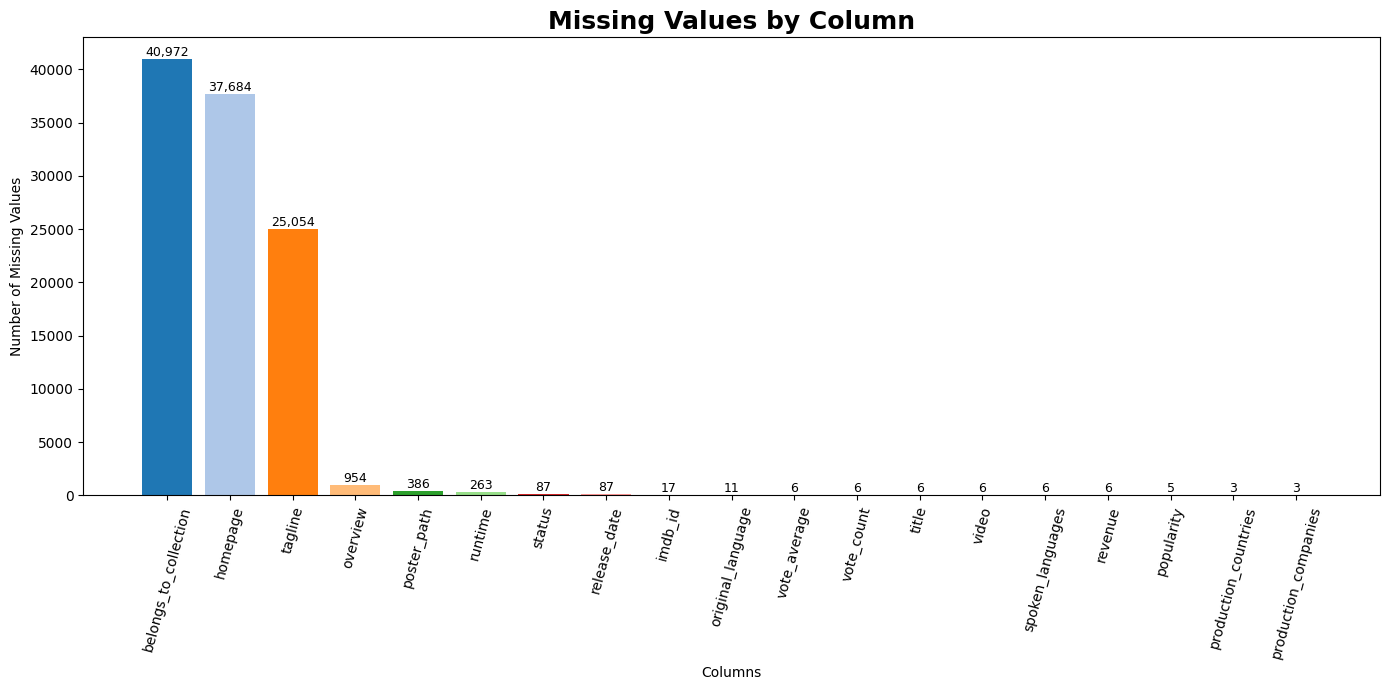

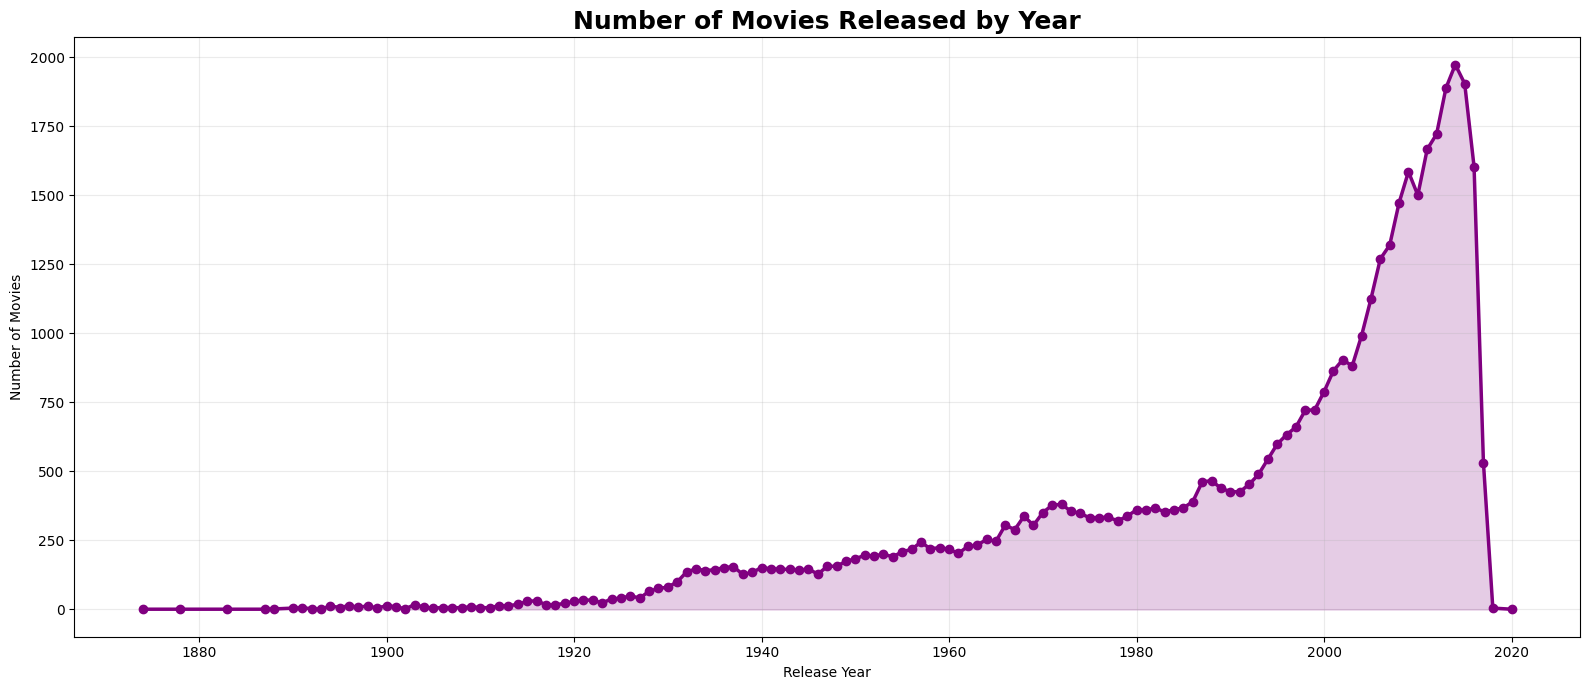

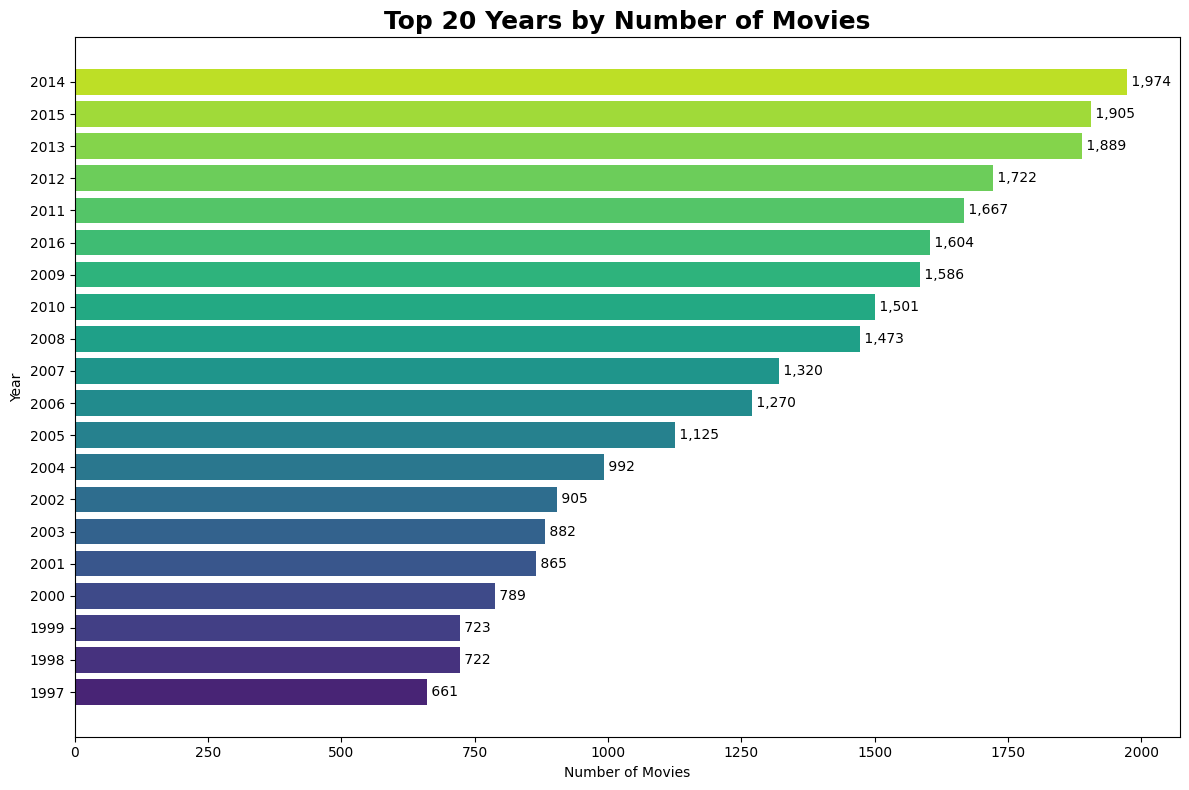

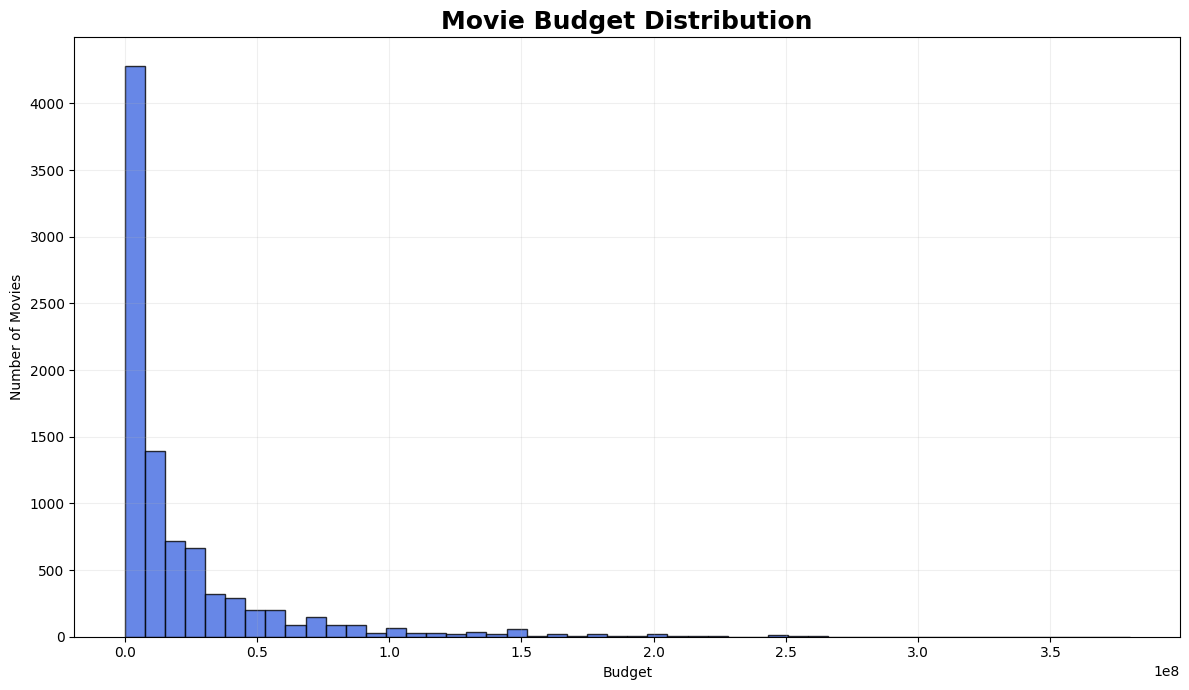

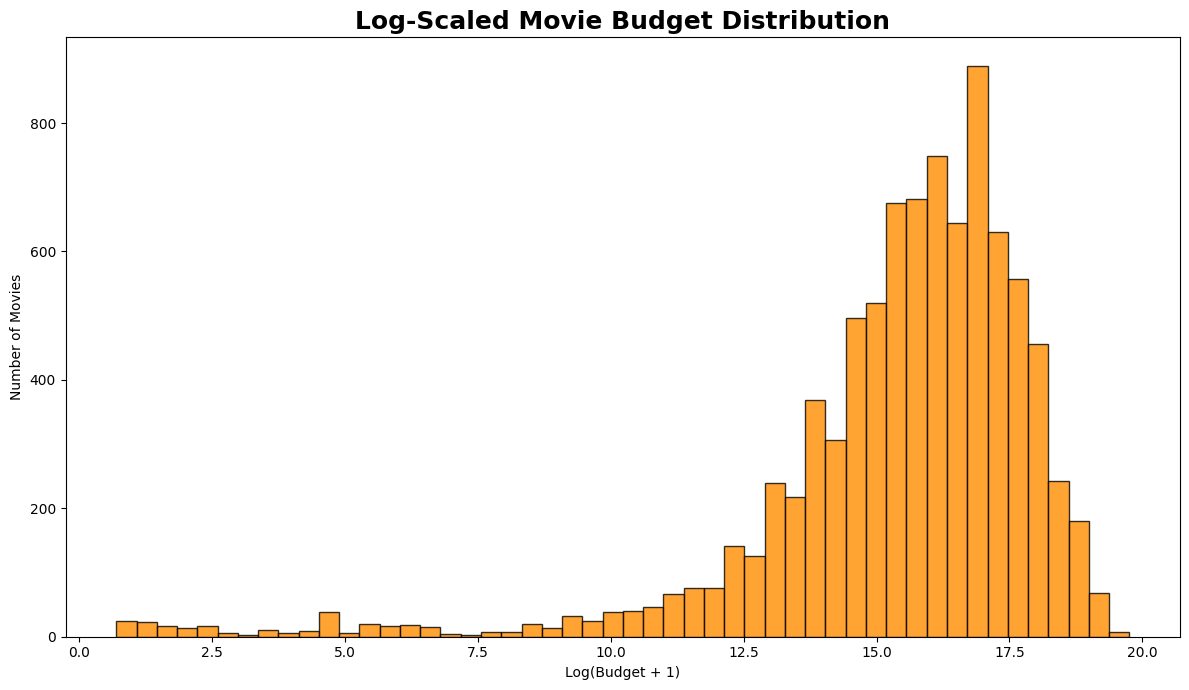

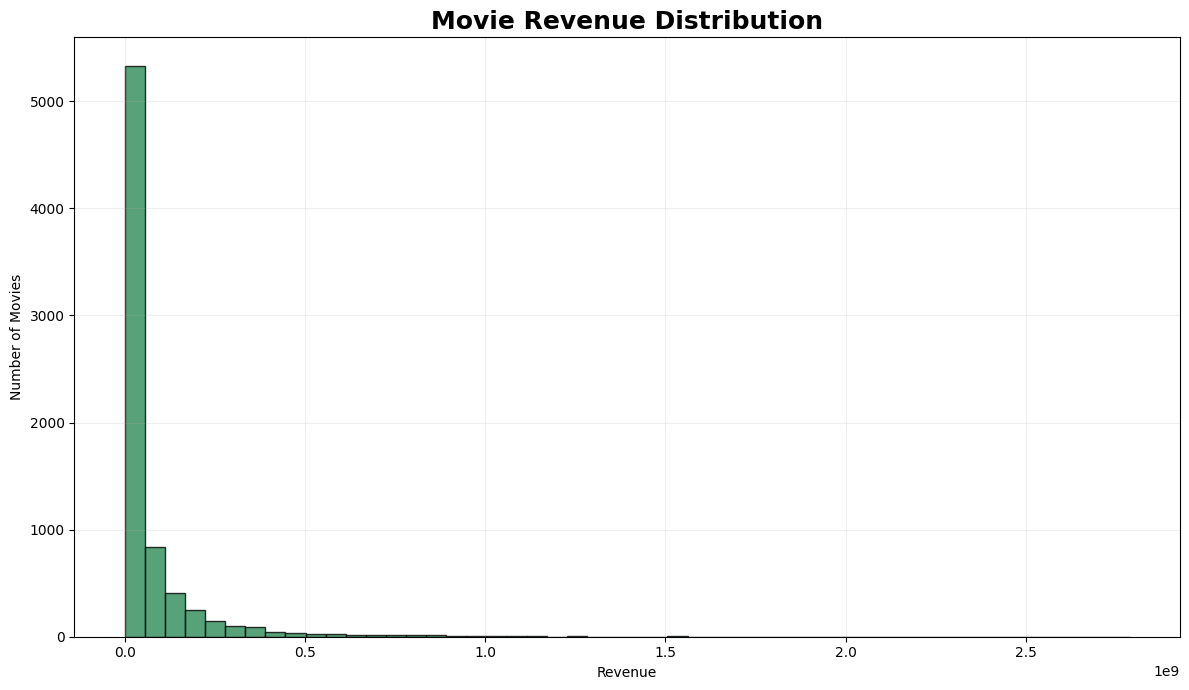

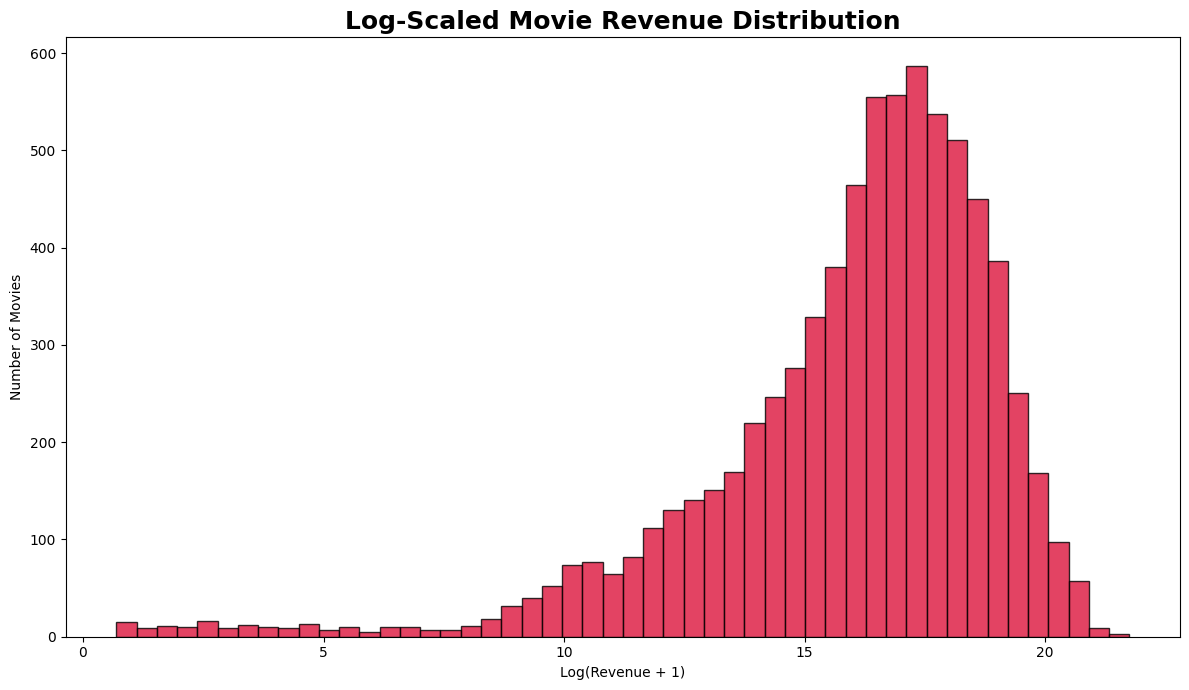

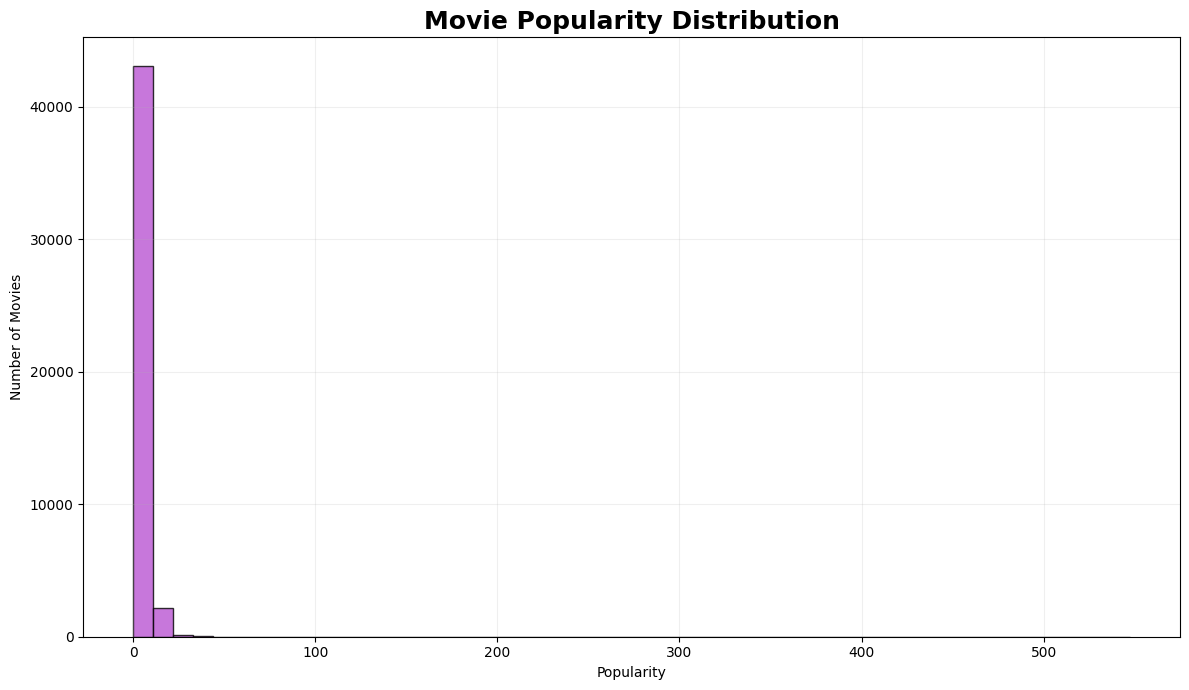

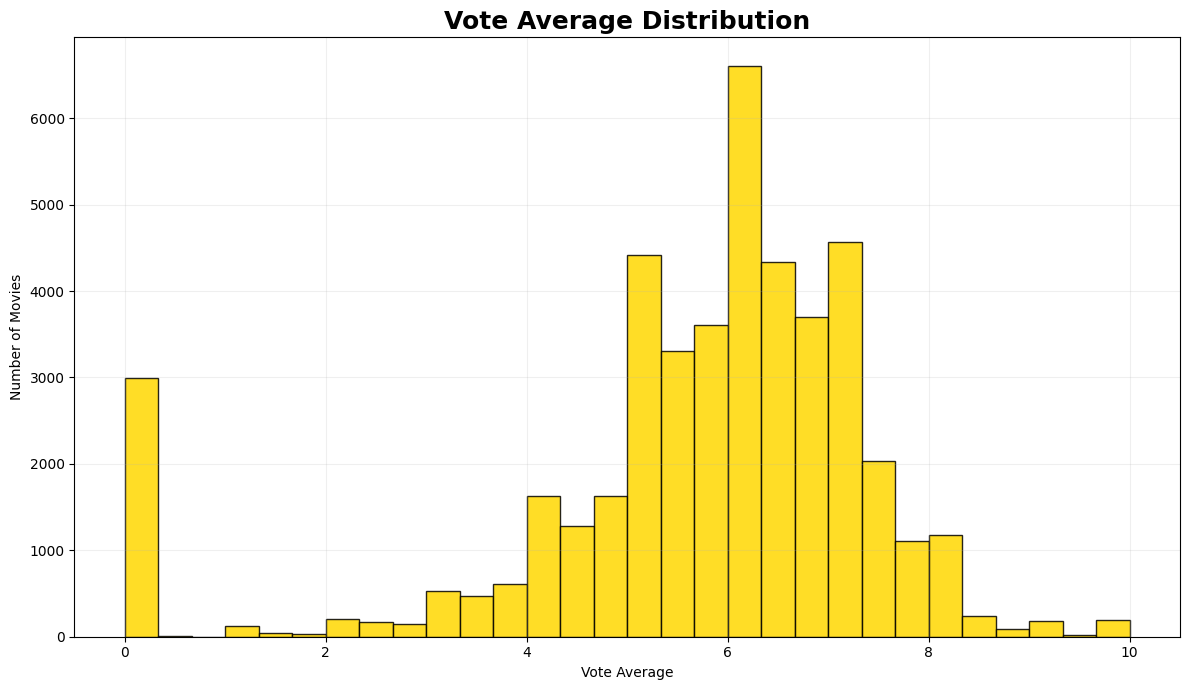

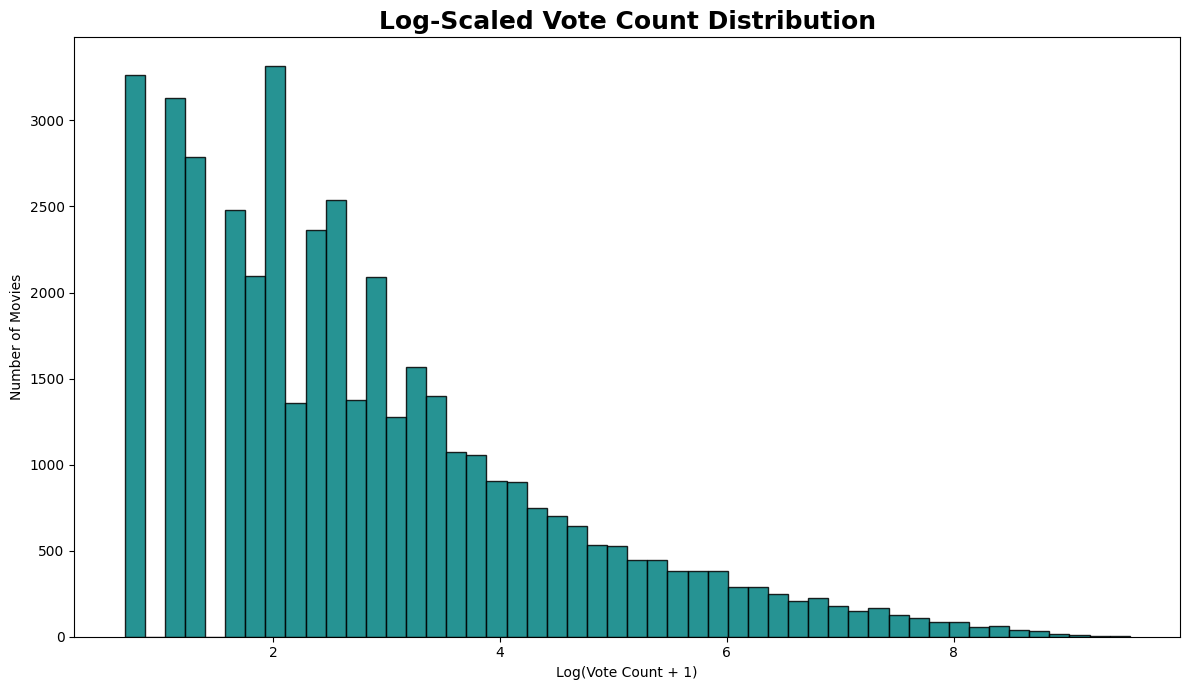

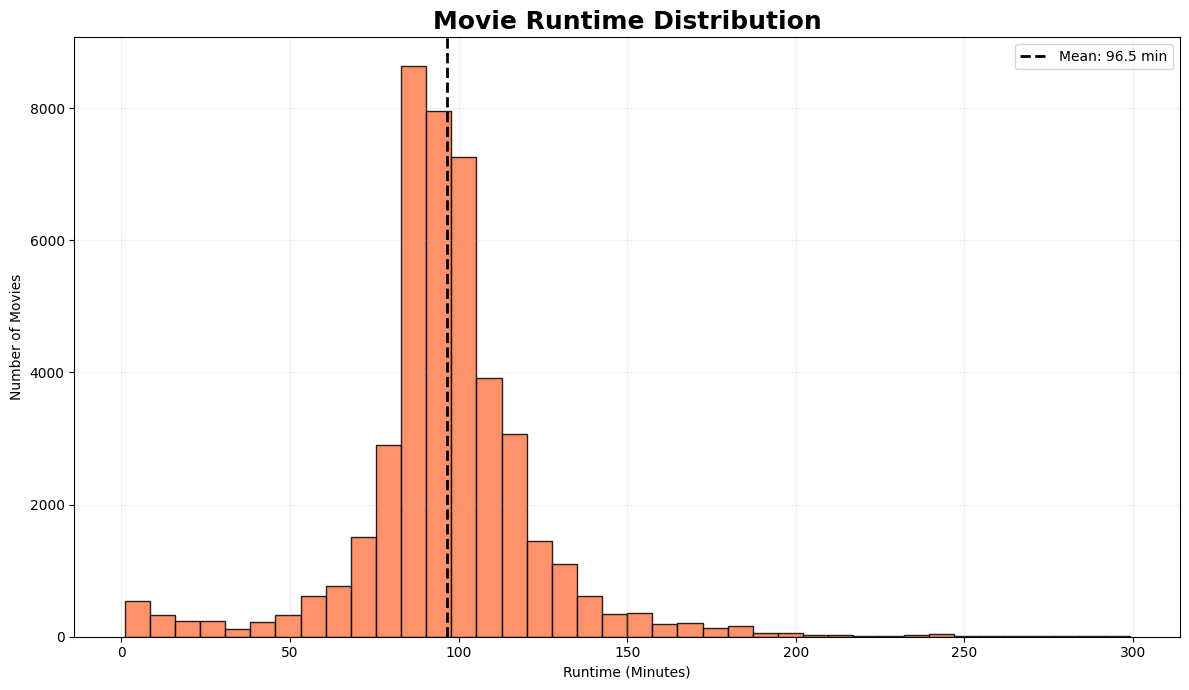

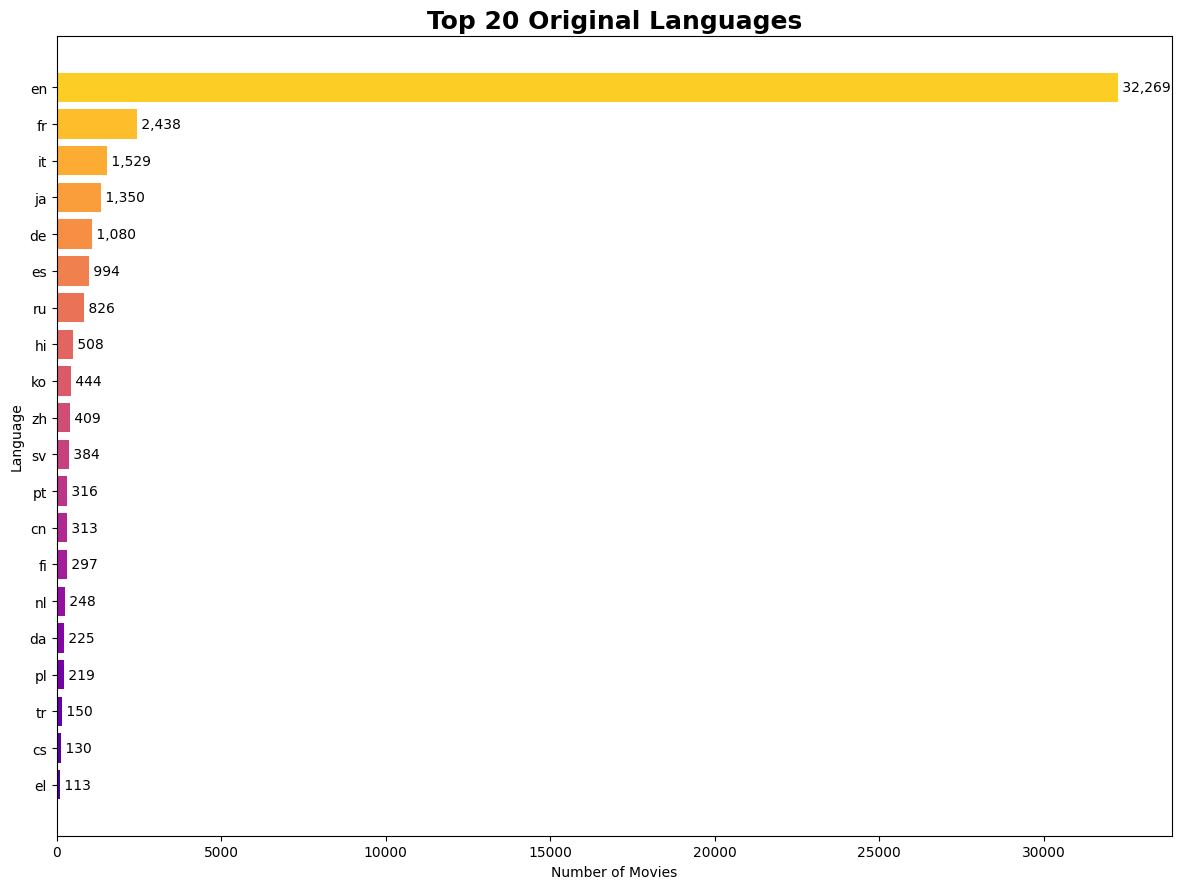

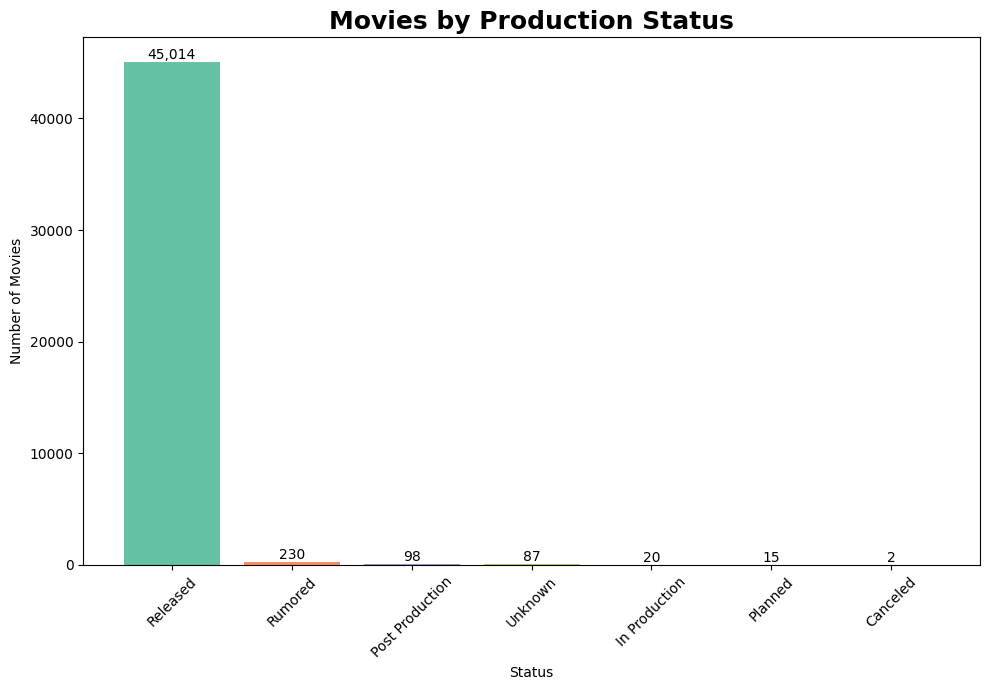

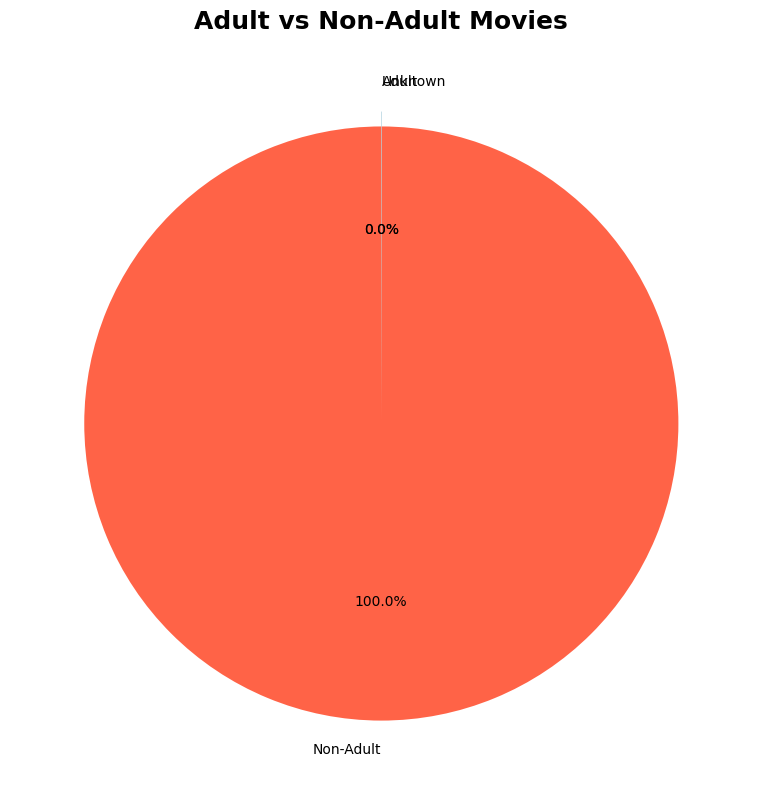

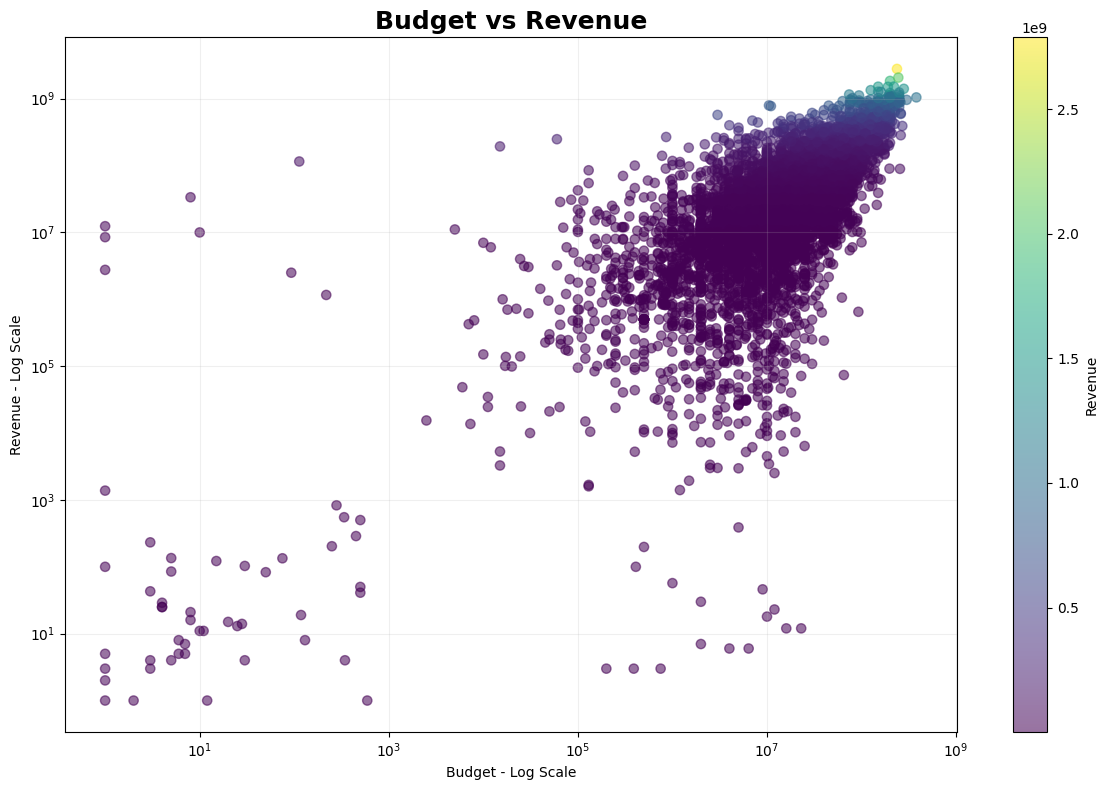

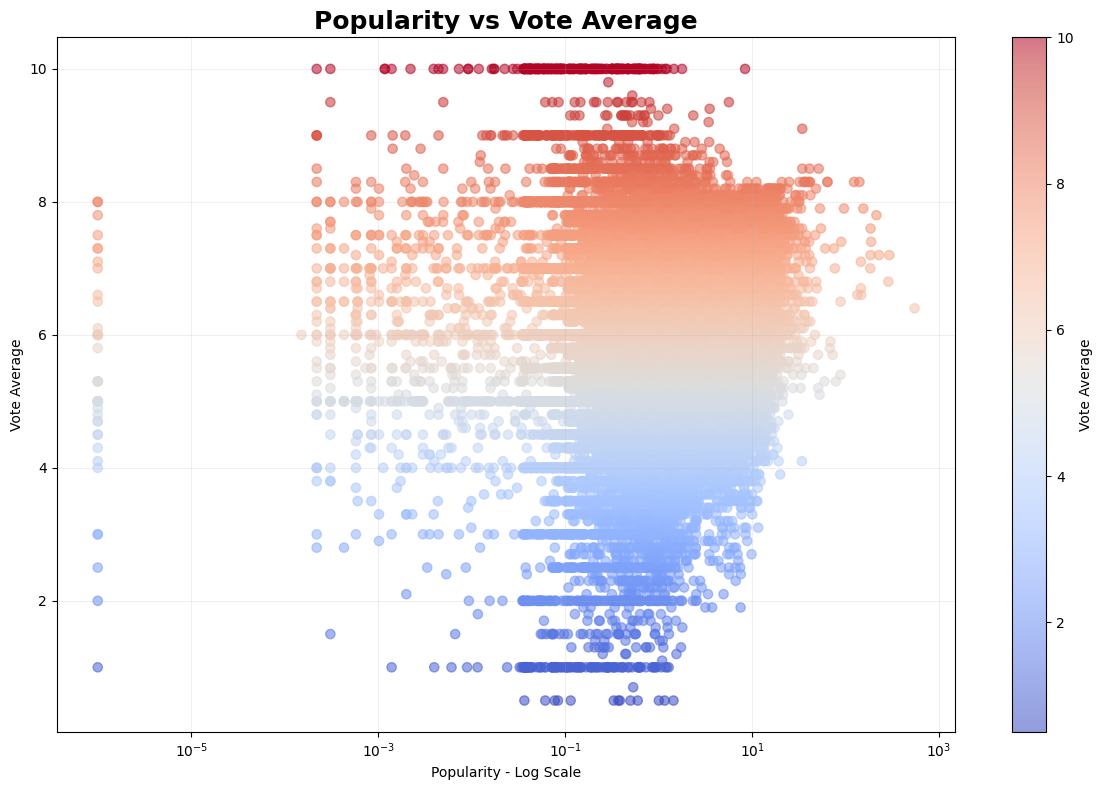

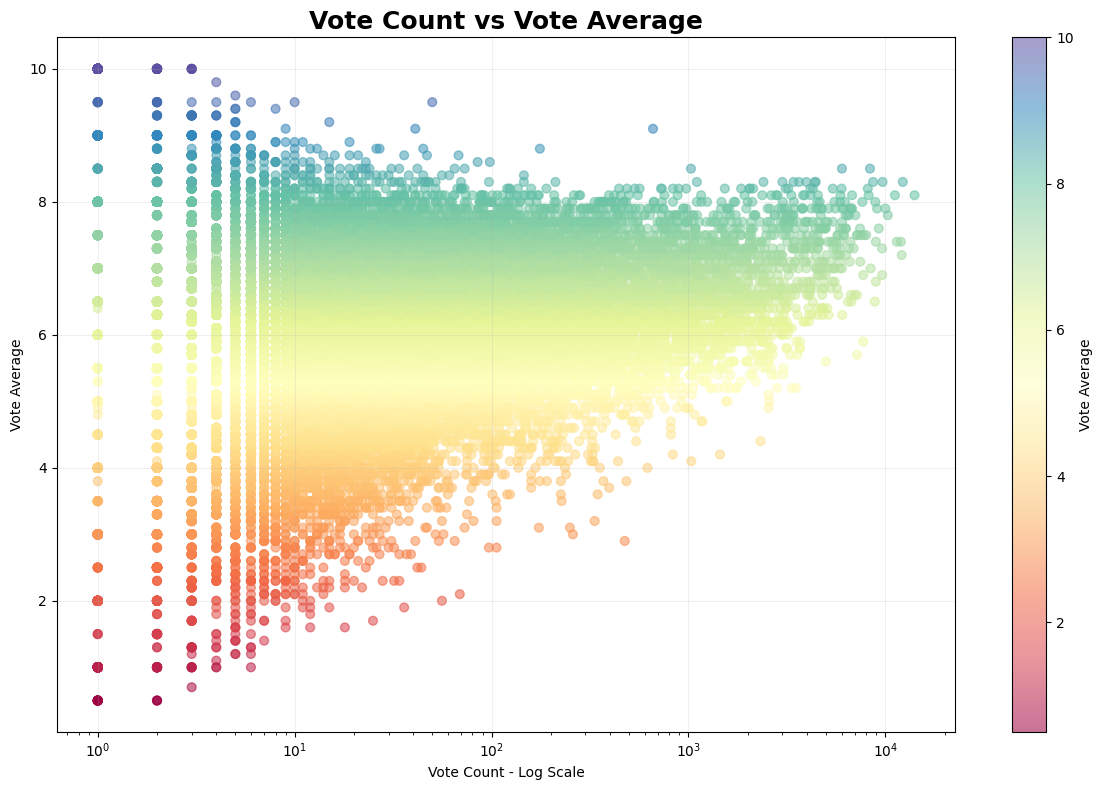

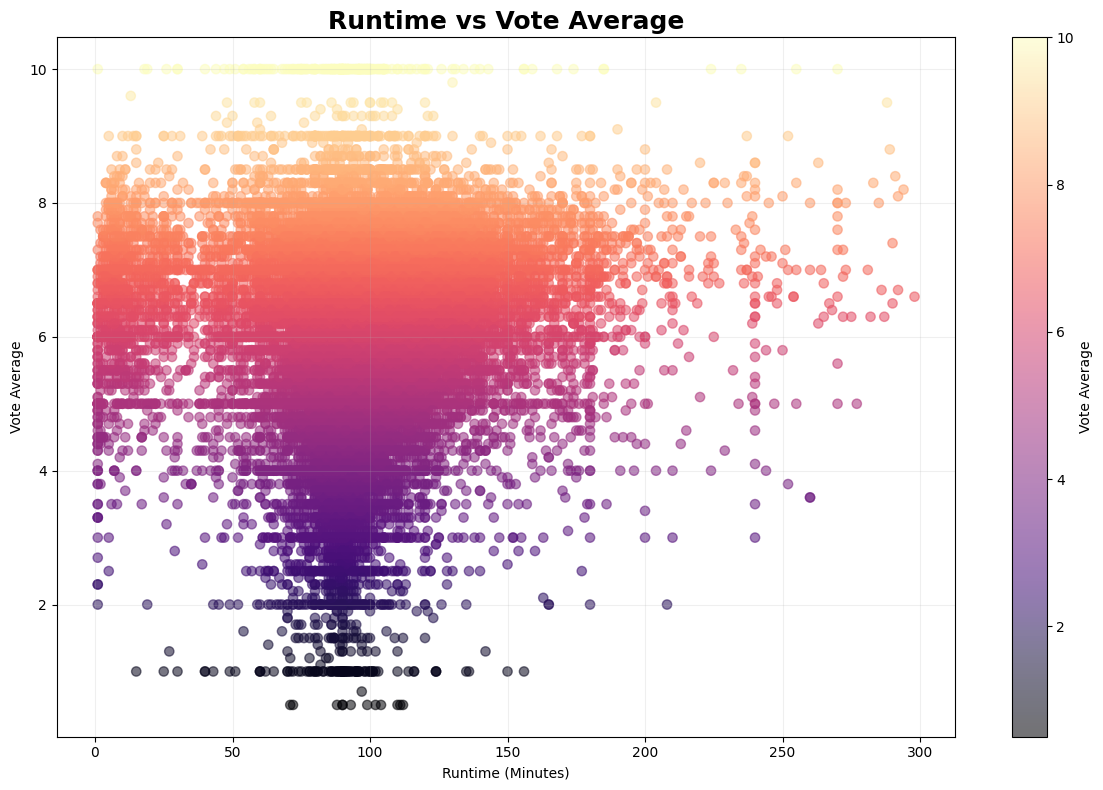

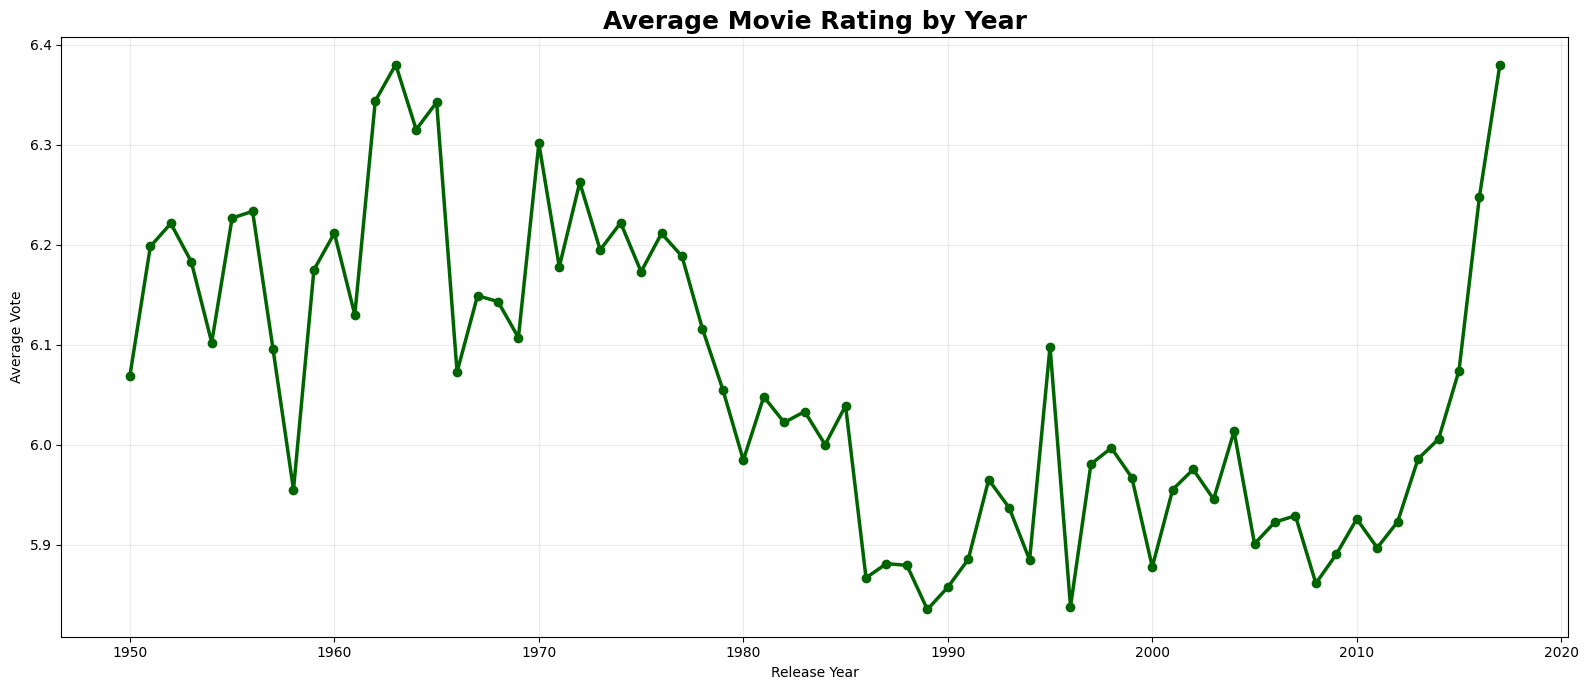

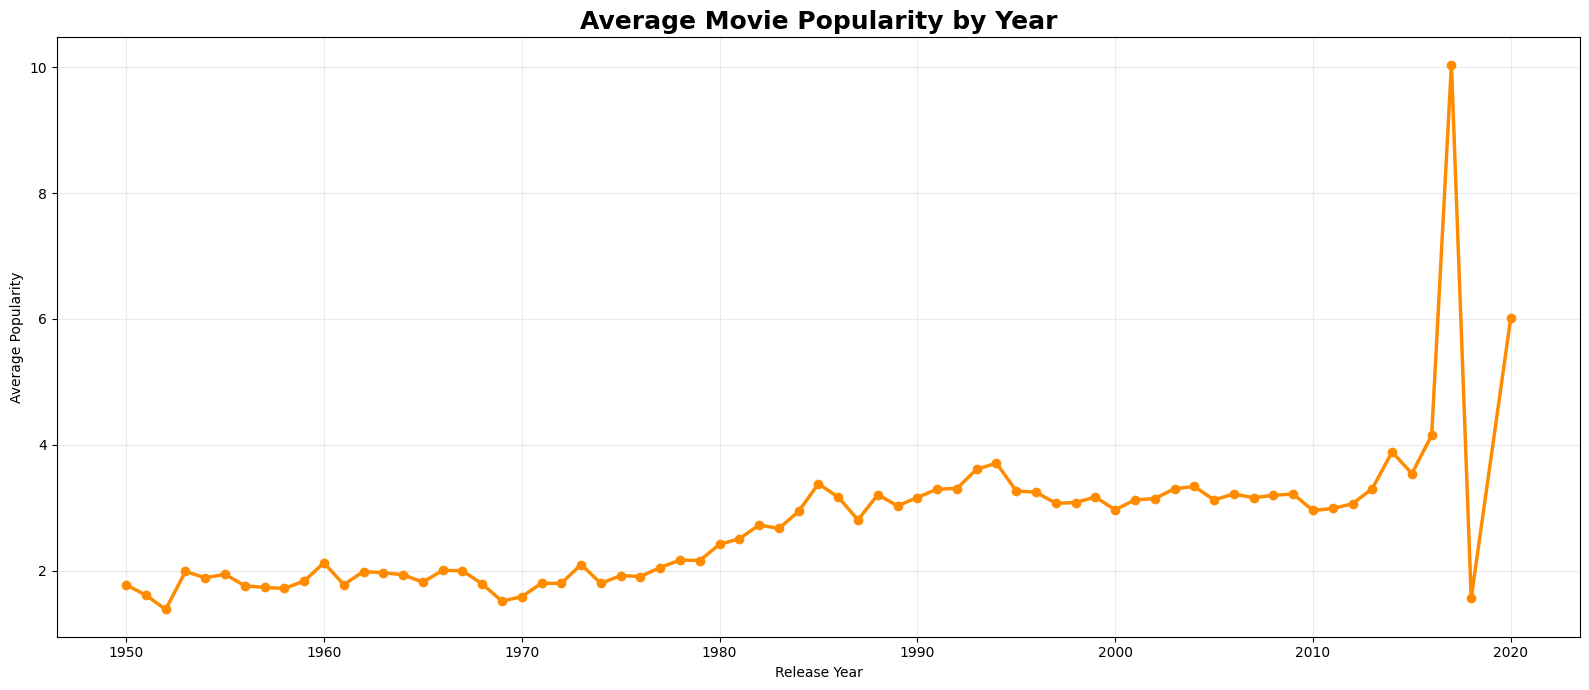

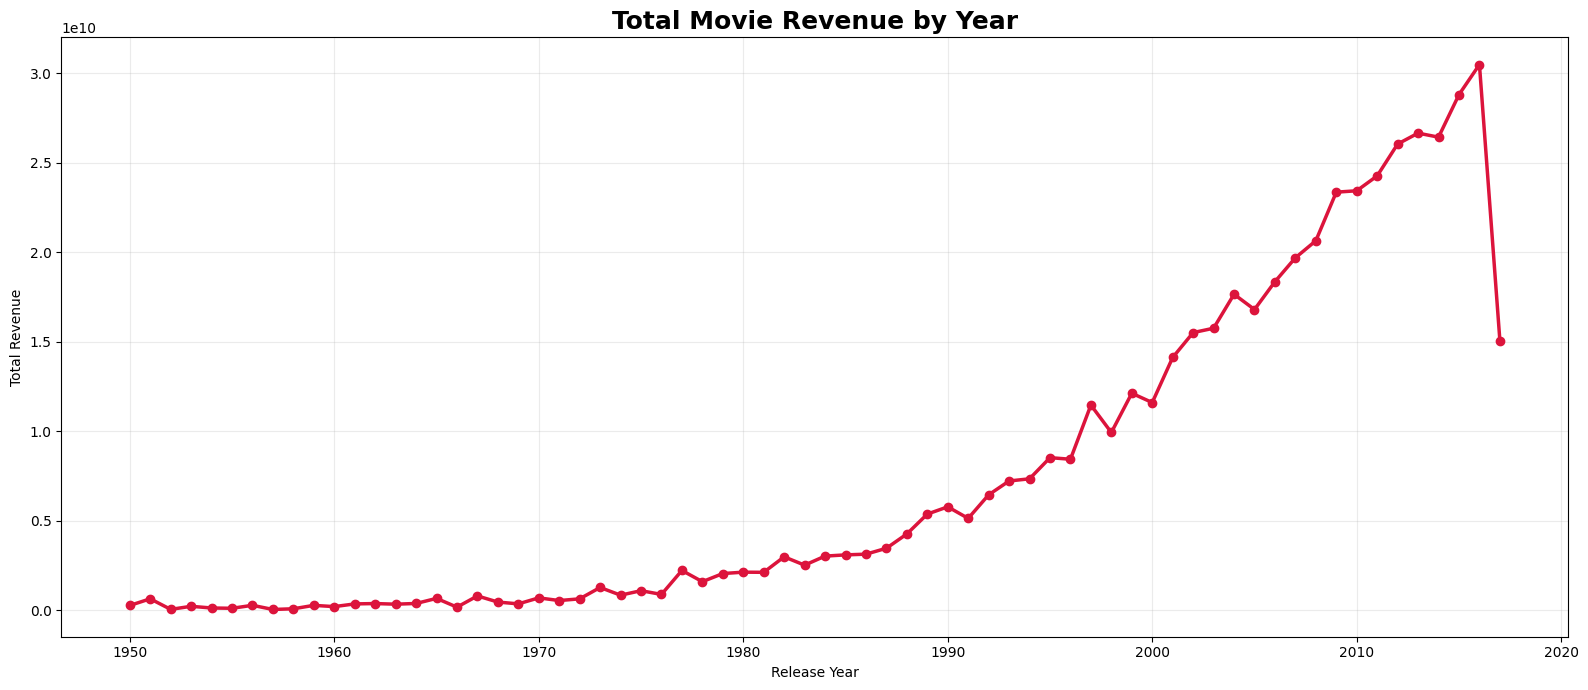

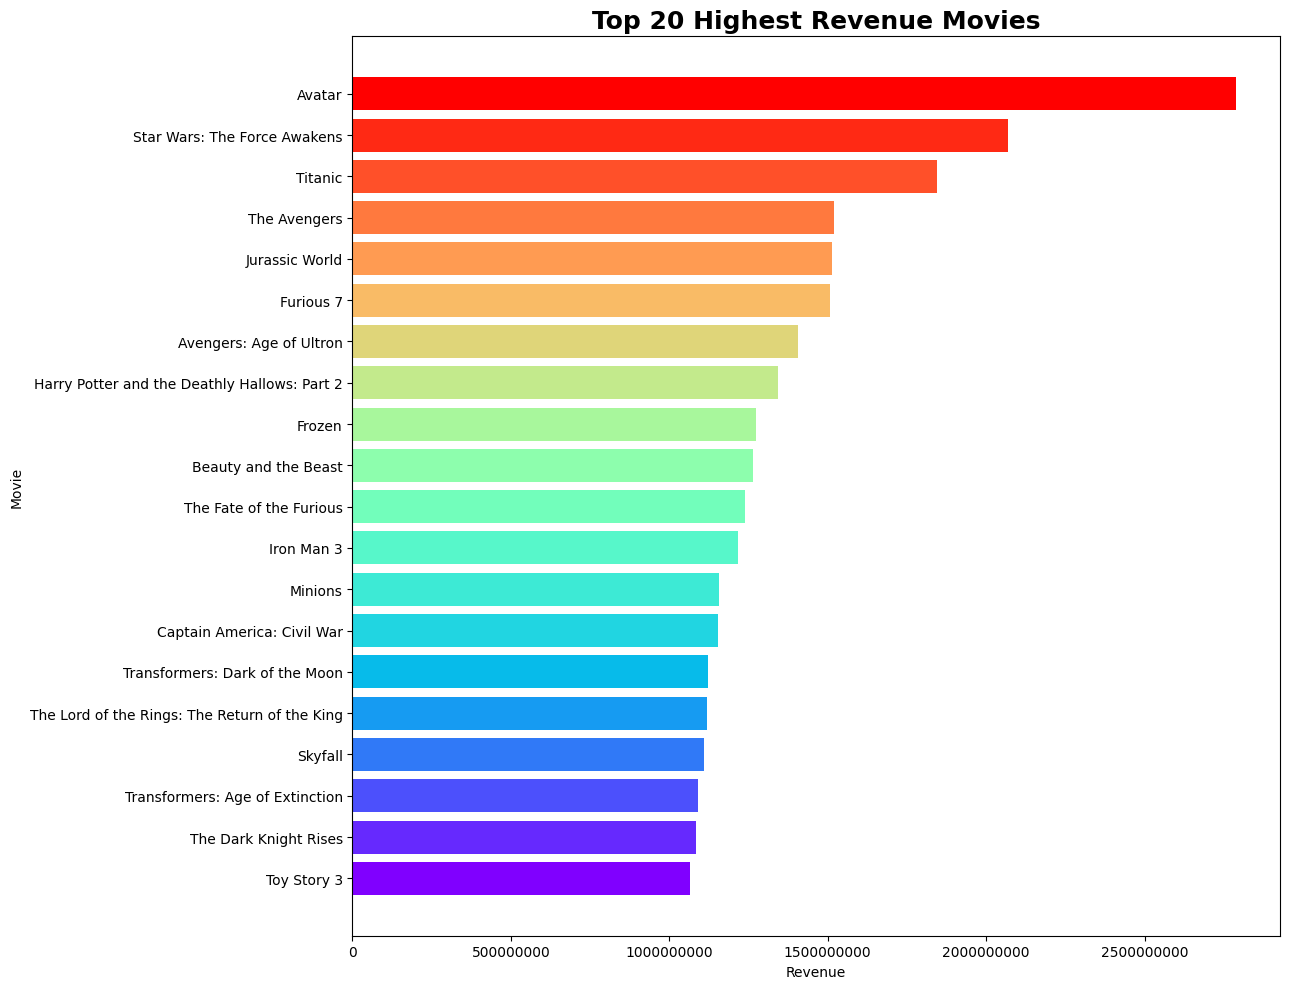

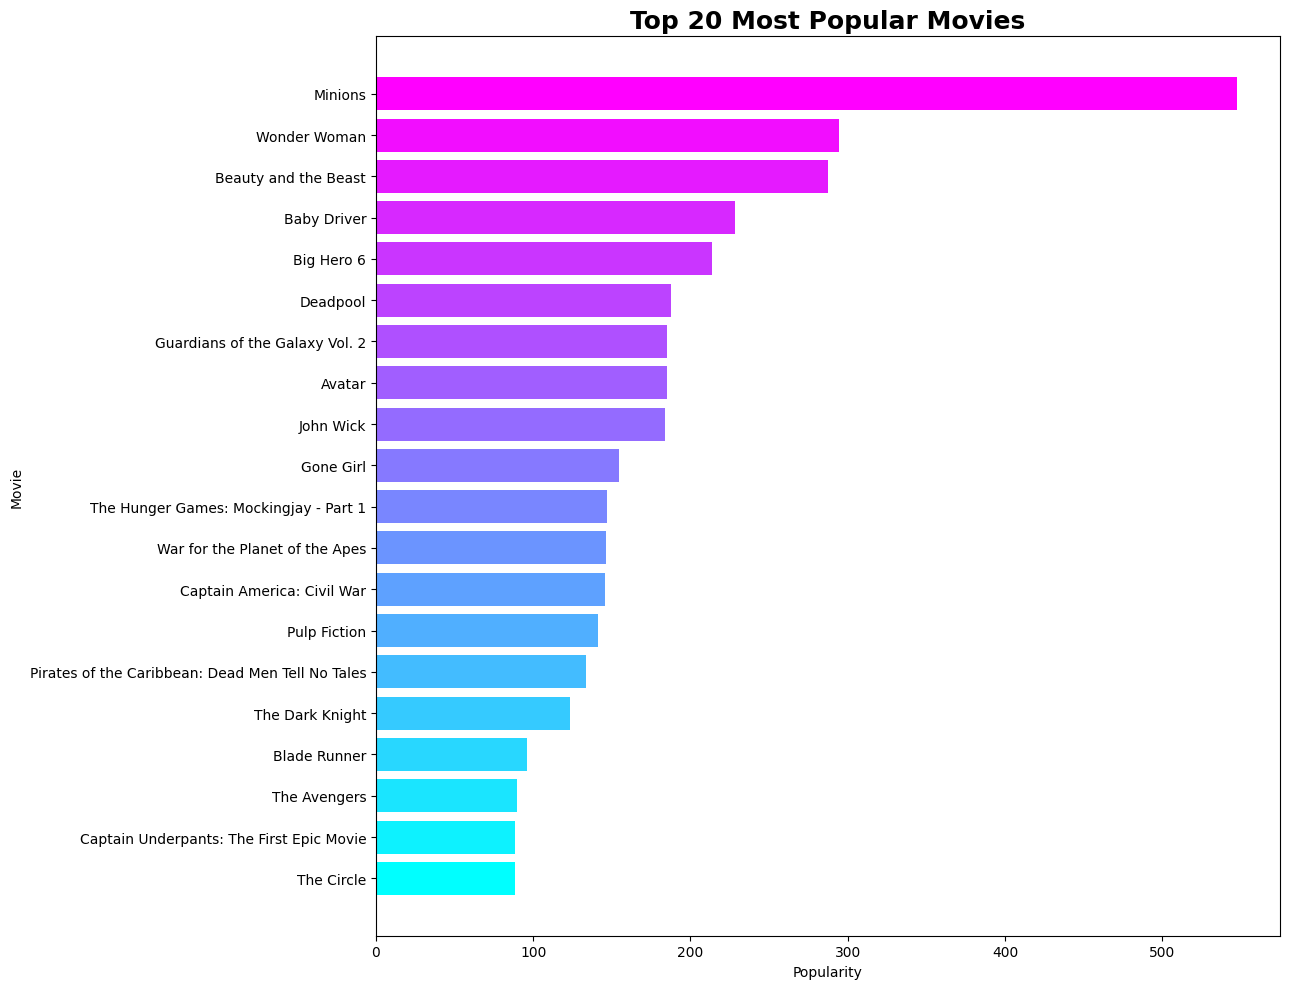

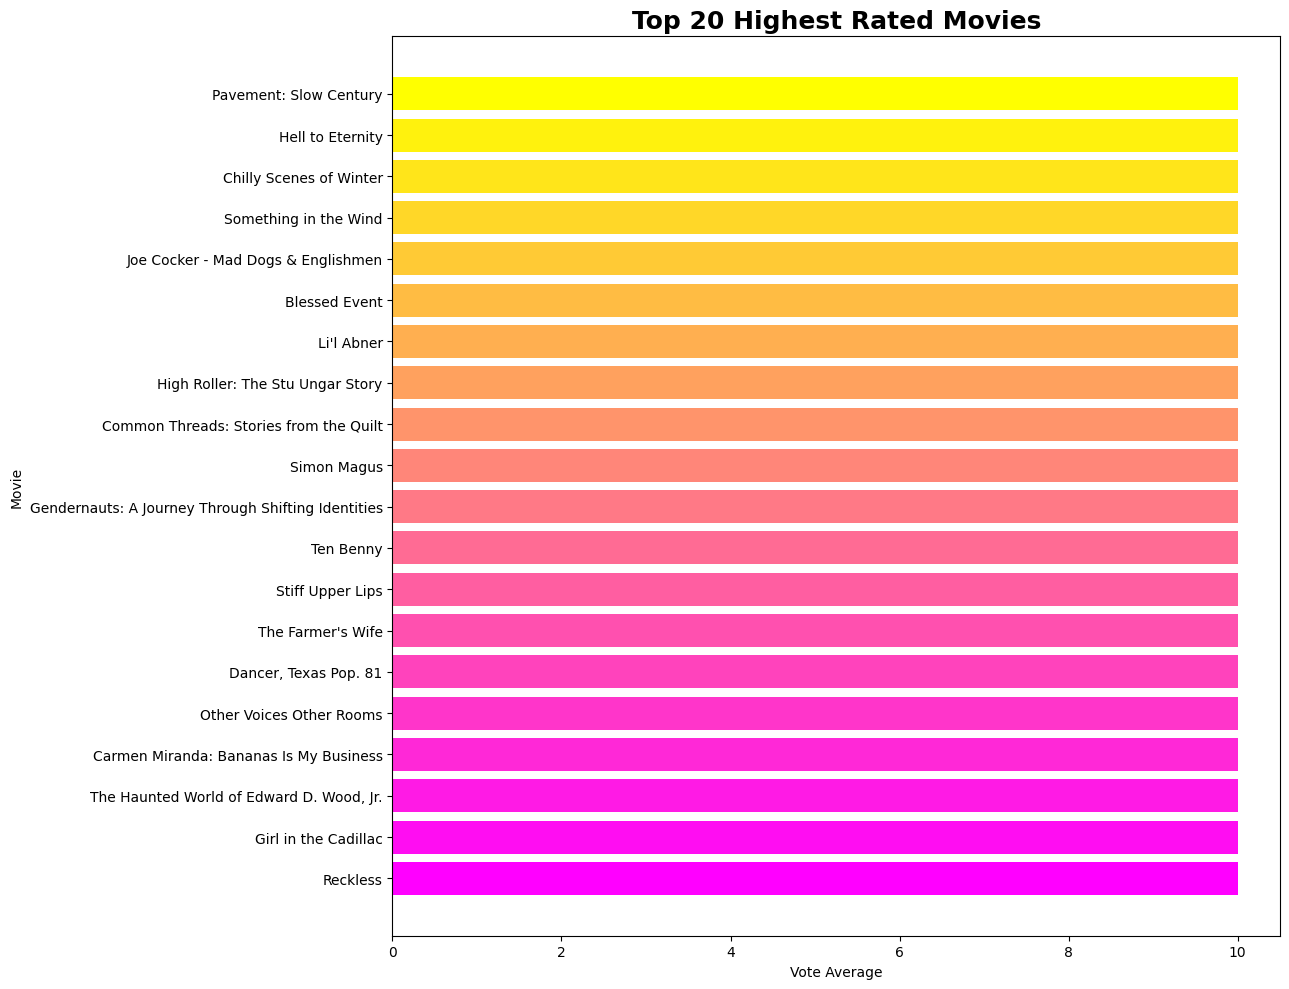

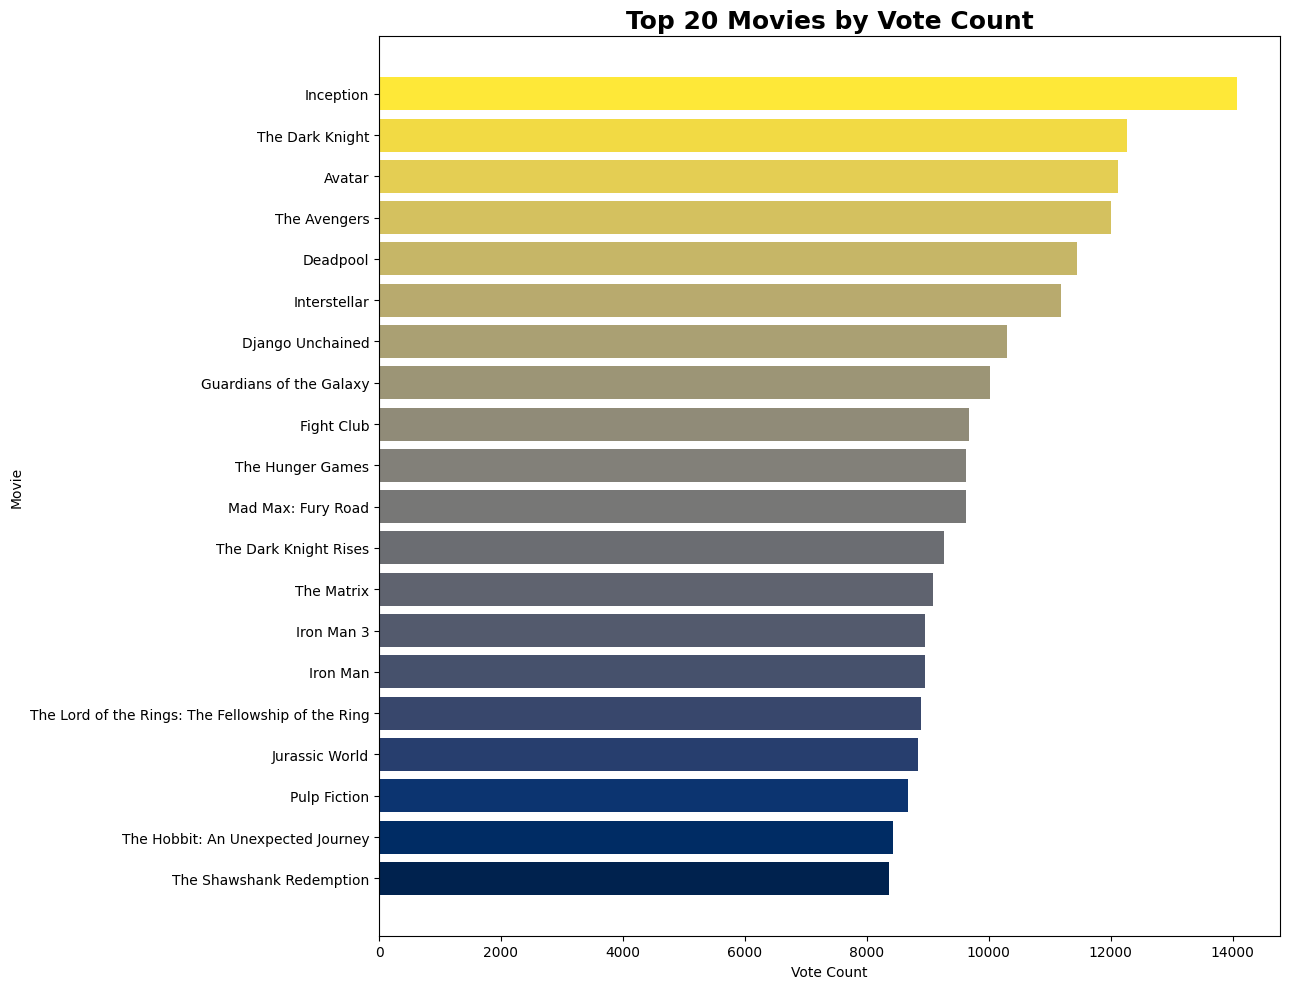

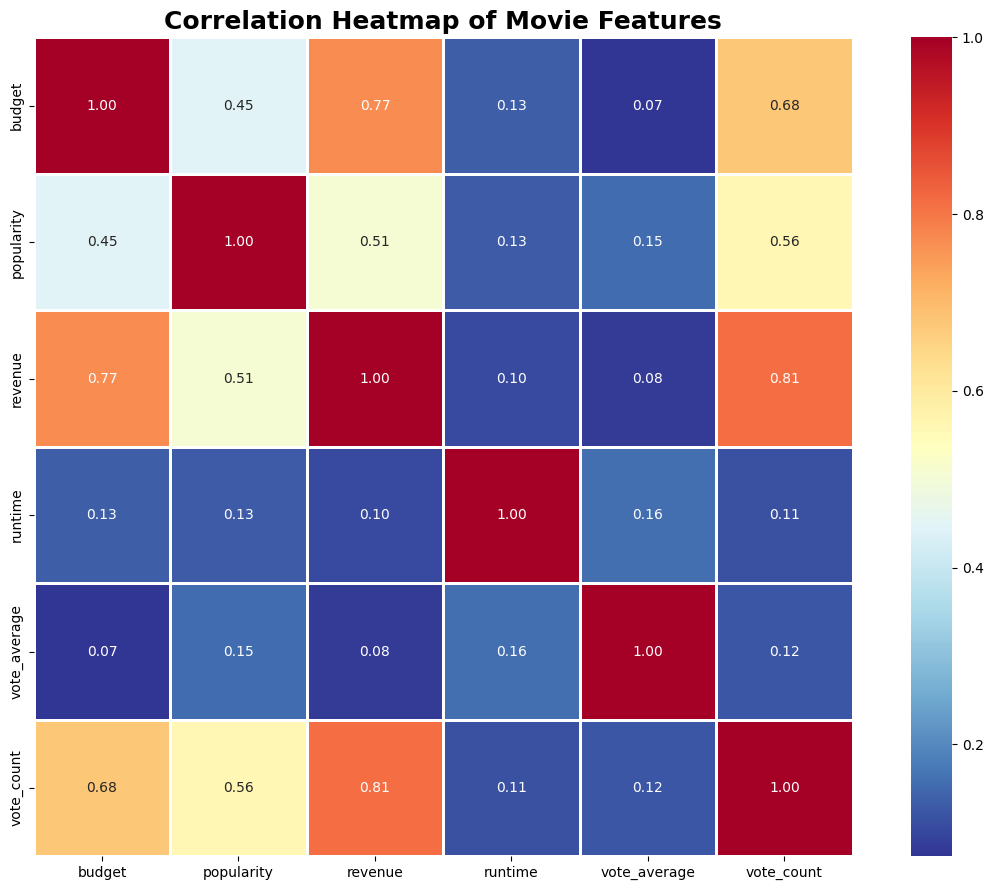

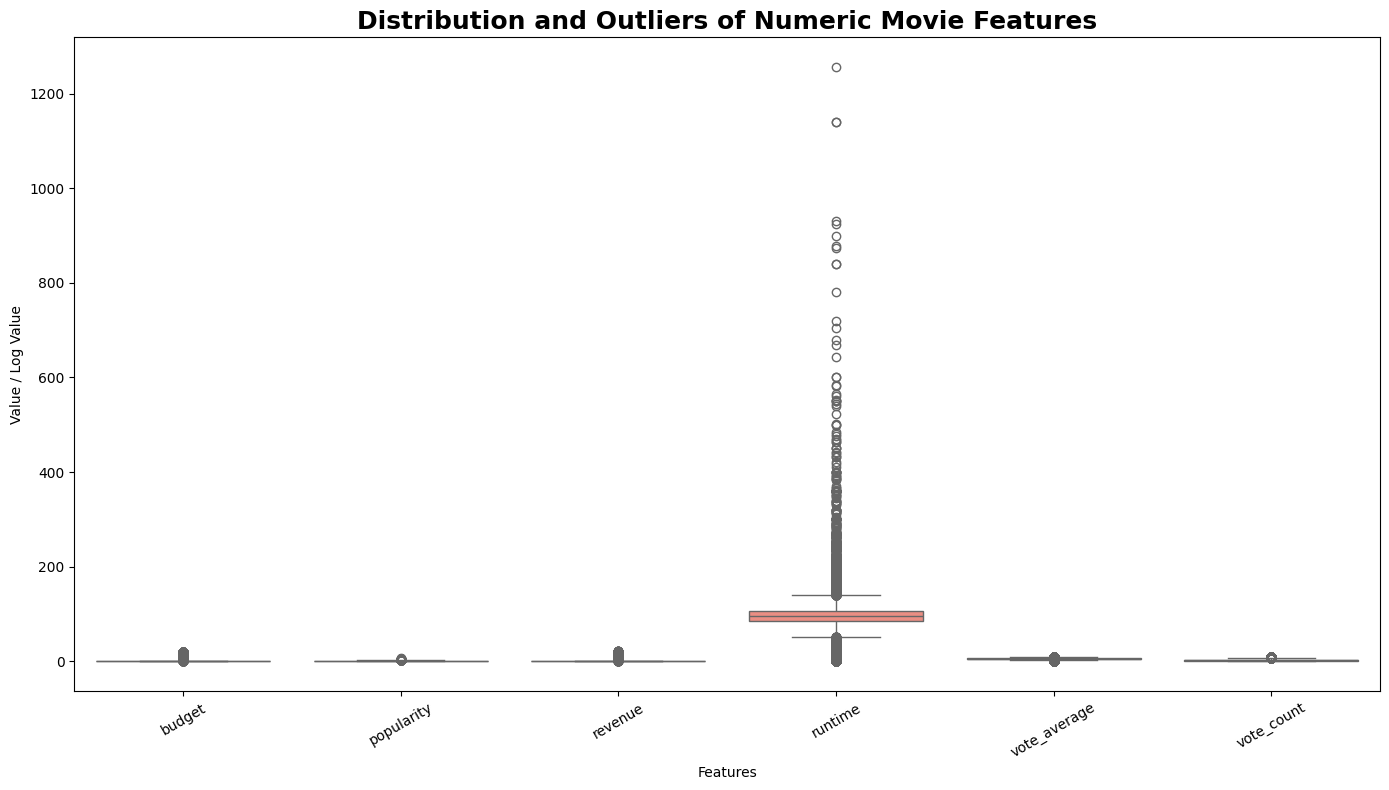

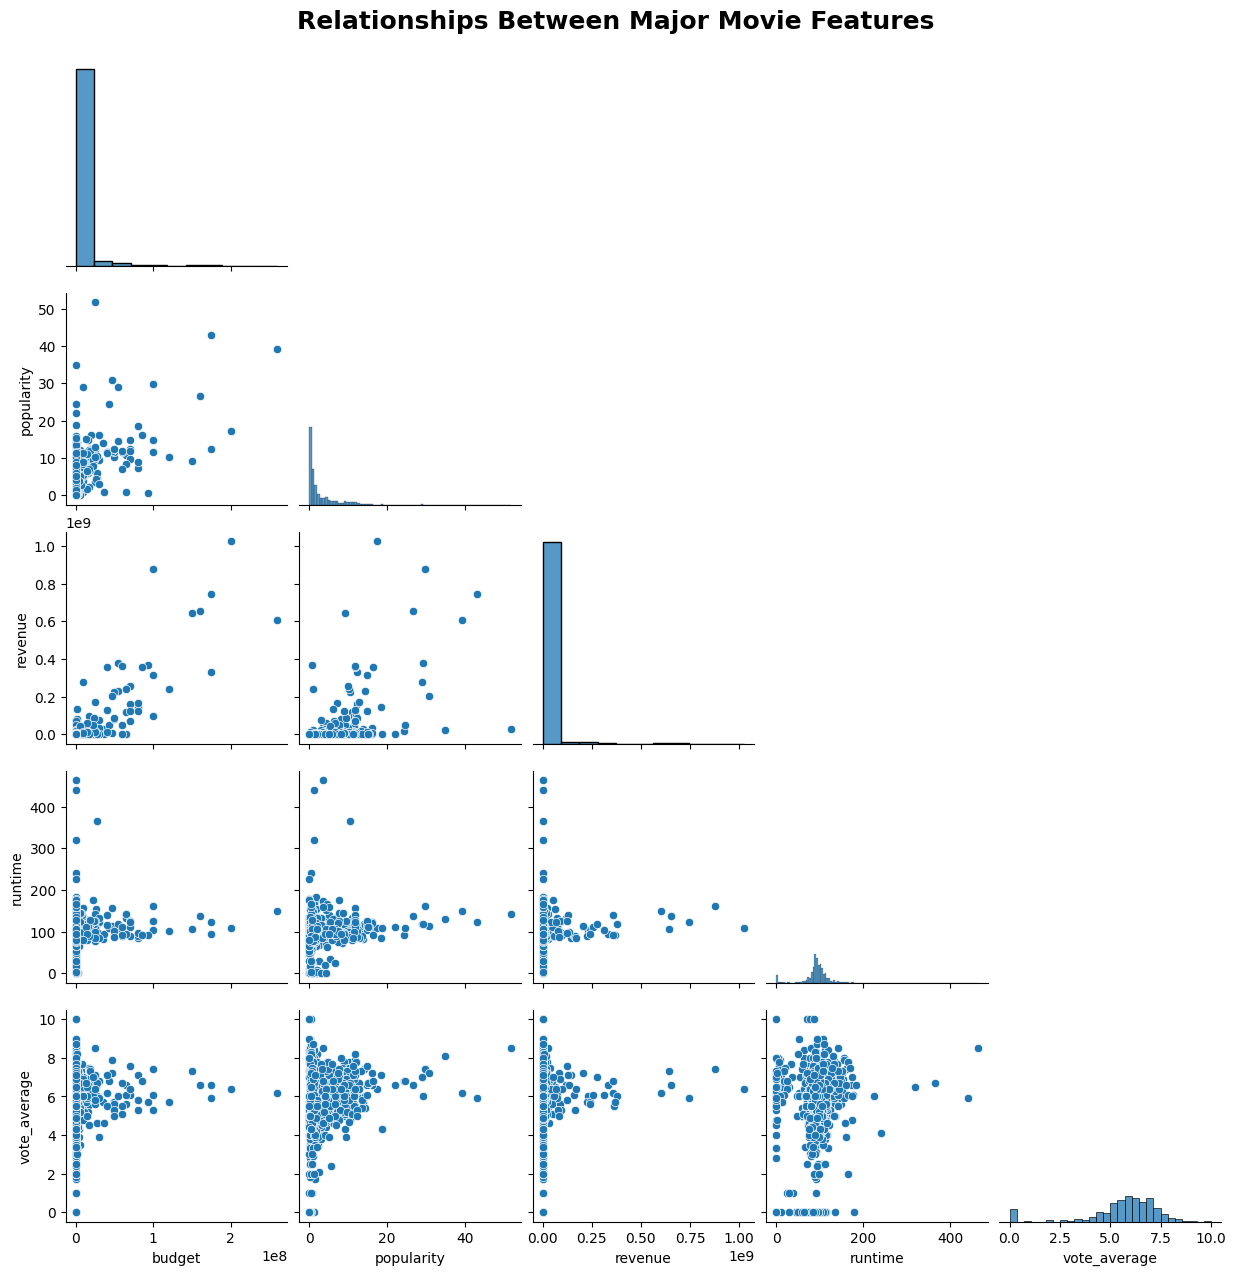

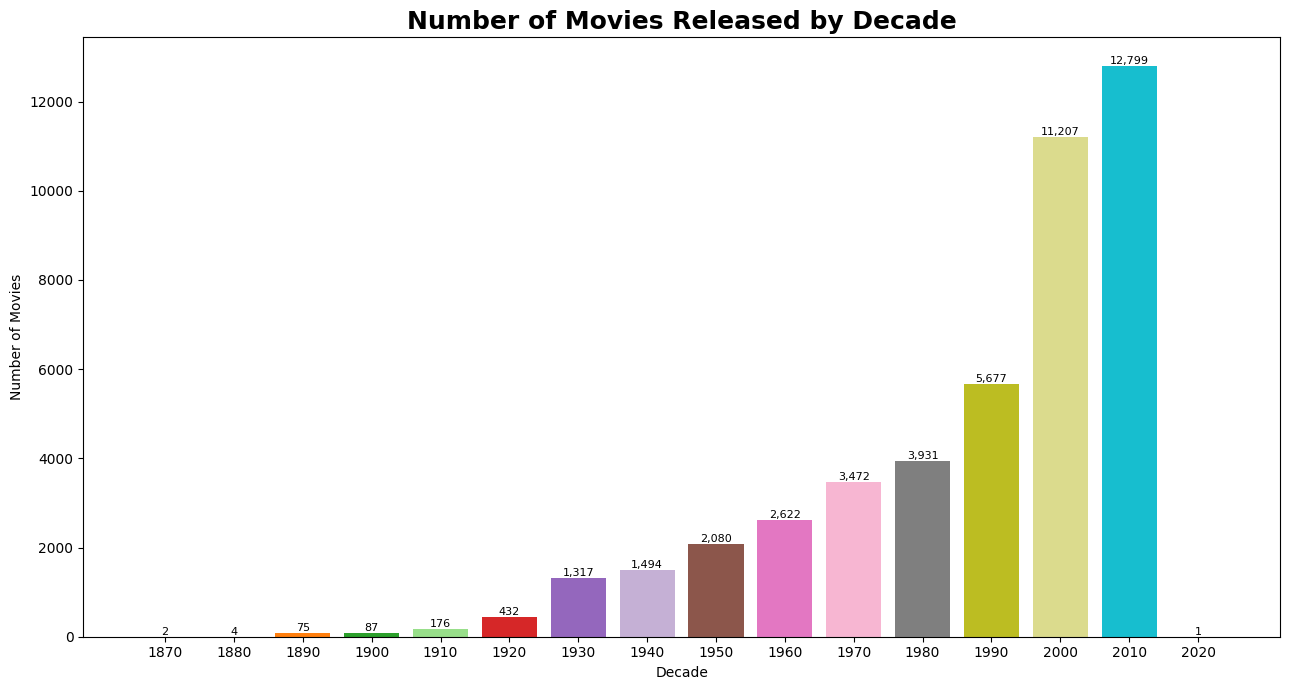

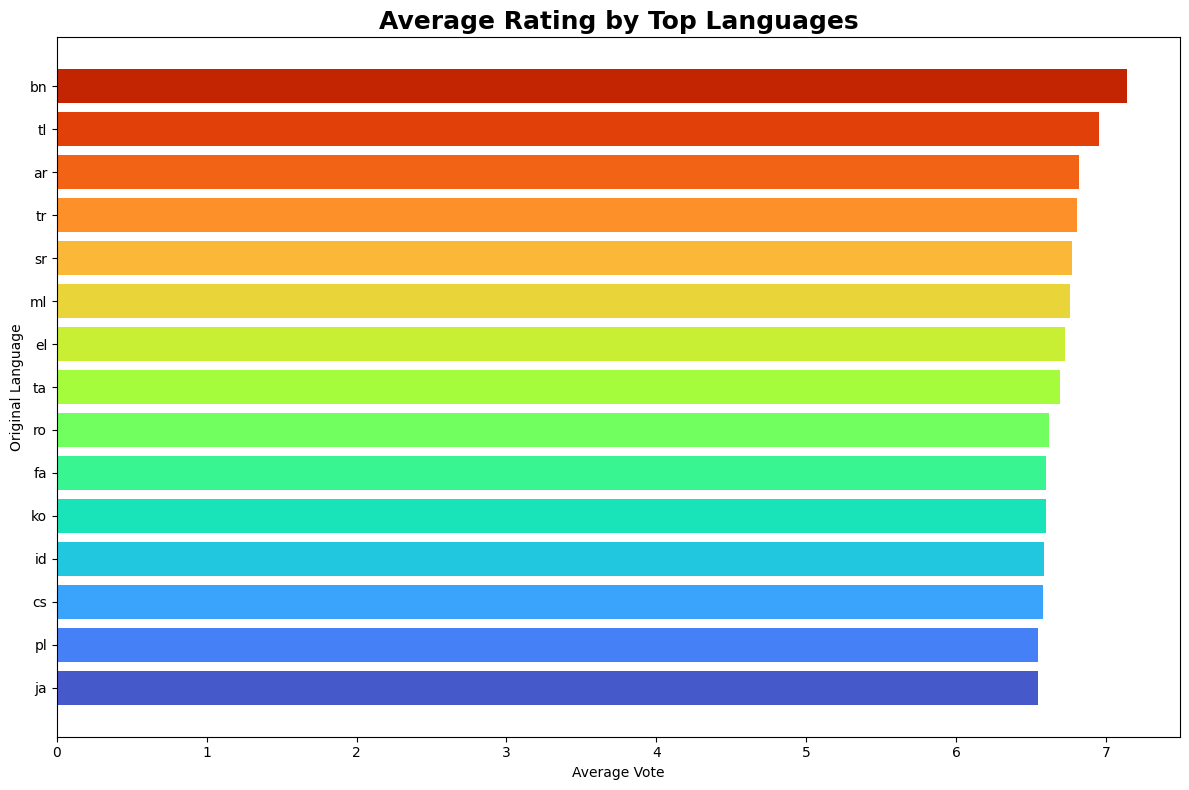

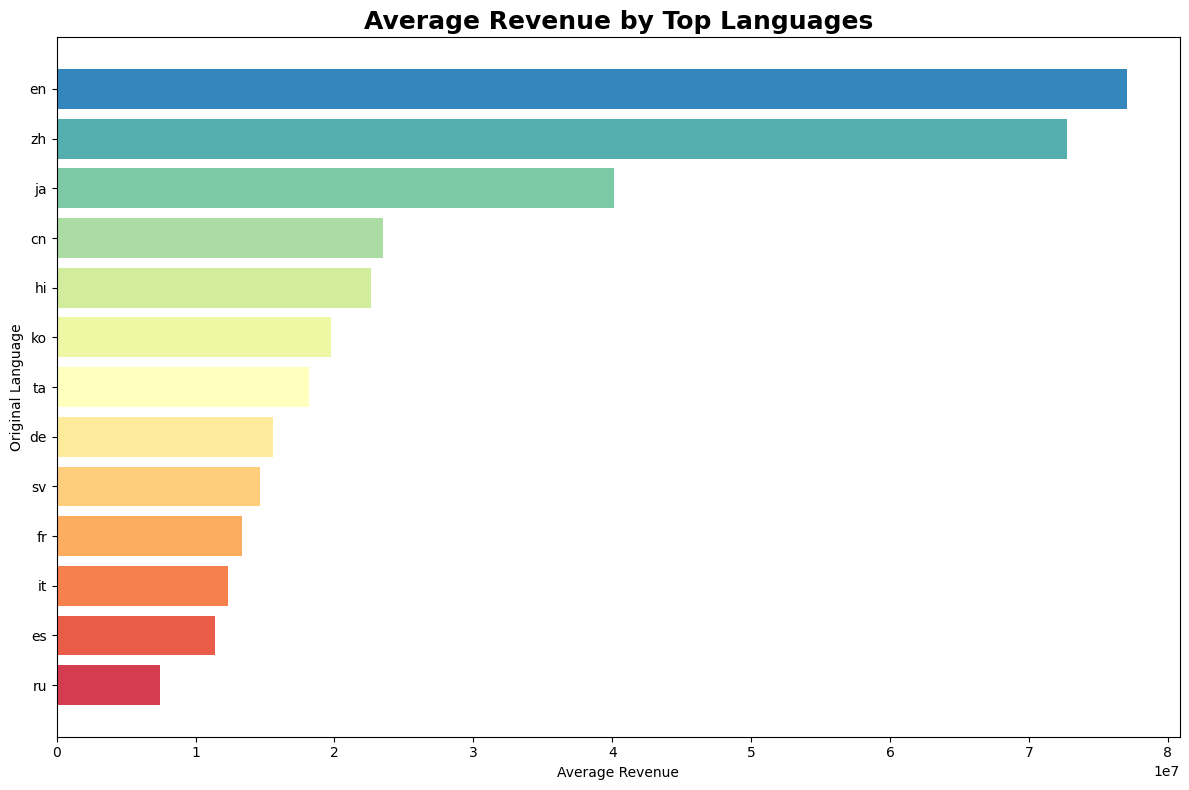

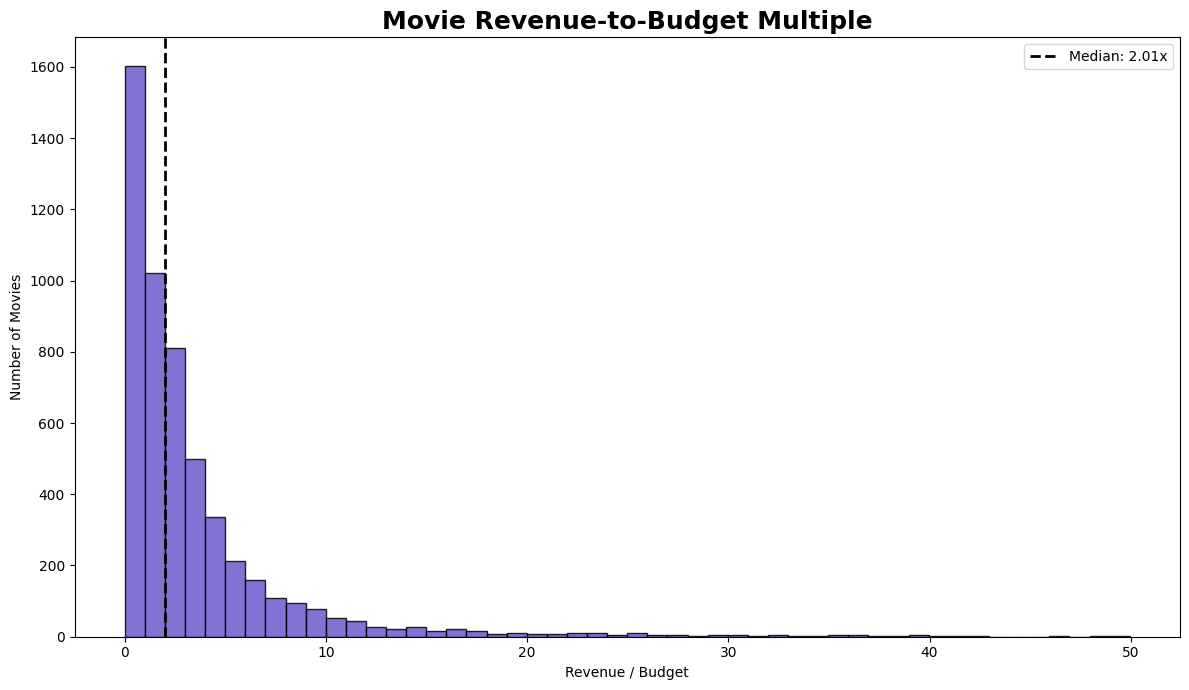

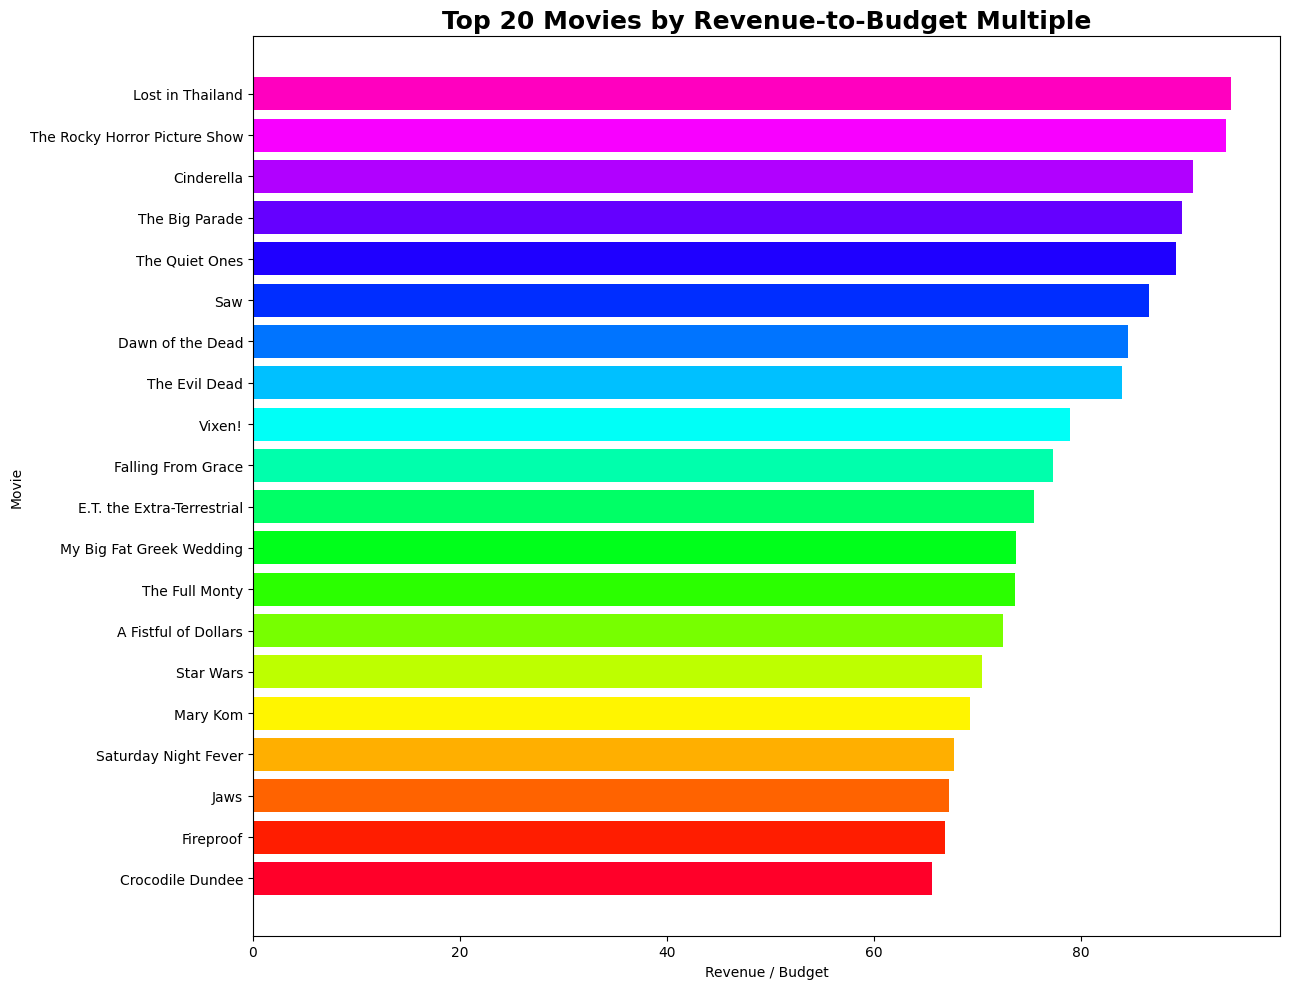


VISUALIZATION COMPLETED
Dataset Shape: (45466, 25)
Release Year Range: 1874 - 2020
Average Budget: 21604277.457480315
Average Revenue: 68787389.92913067
Average Vote: 5.618207215134185

All major visualizations have been generated successfully.


In [13]:

import ast
df = df.copy()

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

# ------------------------------------------------------------
# 2. BASIC DATA INFORMATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATA TYPES")
print("=" * 70)

print(df.dtypes)

print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)

missing = df.isnull().sum().sort_values(ascending=False)

print(missing)

# ------------------------------------------------------------
# 3. MISSING VALUE VISUALIZATION
# ------------------------------------------------------------

missing_plot = missing[missing > 0]

if len(missing_plot) > 0:

    plt.figure(figsize=(14, 7))

    bars = plt.bar(
        missing_plot.index,
        missing_plot.values,
        color=plt.cm.tab20(np.linspace(0, 1, len(missing_plot)))
    )

    plt.title(
        "Missing Values by Column",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Columns")
    plt.ylabel("Number of Missing Values")
    plt.xticks(rotation=75)

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{int(height):,}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 4. DATA CLEANING FOR VISUALIZATION
# ------------------------------------------------------------

# Convert numeric columns safely

numeric_columns = [
    "budget",
    "popularity",
    "revenue",
    "runtime",
    "vote_average",
    "vote_count"
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


# Convert release date

if "release_date" in df.columns:

    df["release_date"] = pd.to_datetime(
        df["release_date"],
        errors="coerce"
    )

    df["release_year"] = df["release_date"].dt.year


# ------------------------------------------------------------
# 5. MOVIES RELEASED BY YEAR
# ------------------------------------------------------------

if "release_year" in df.columns:

    year_count = (
        df["release_year"]
        .dropna()
        .astype(int)
        .value_counts()
        .sort_index()
    )

    plt.figure(figsize=(16, 7))

    plt.plot(
        year_count.index,
        year_count.values,
        marker="o",
        linewidth=2.5,
        color="purple"
    )

    plt.fill_between(
        year_count.index,
        year_count.values,
        alpha=0.20,
        color="purple"
    )

    plt.title(
        "Number of Movies Released by Year",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Release Year")
    plt.ylabel("Number of Movies")
    plt.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 6. TOP 20 YEARS BY MOVIE COUNT
# ------------------------------------------------------------

if "release_year" in df.columns:

    top_years = (
        df["release_year"]
        .dropna()
        .astype(int)
        .value_counts()
        .head(20)
        .sort_values(ascending=True)
    )

    plt.figure(figsize=(12, 8))

    bars = plt.barh(
        top_years.index.astype(str),
        top_years.values,
        color=plt.cm.viridis(
            np.linspace(0.1, 0.9, len(top_years))
        )
    )

    plt.title(
        "Top 20 Years by Number of Movies",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Number of Movies")
    plt.ylabel("Year")

    for bar in bars:
        plt.text(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2,
            f" {int(bar.get_width()):,}",
            va="center"
        )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 7. BUDGET DISTRIBUTION
# ------------------------------------------------------------

if "budget" in df.columns:

    budget_data = df.loc[df["budget"] > 0, "budget"]

    plt.figure(figsize=(12, 7))

    plt.hist(
        budget_data,
        bins=50,
        color="royalblue",
        edgecolor="black",
        alpha=0.80
    )

    plt.title(
        "Movie Budget Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Budget")
    plt.ylabel("Number of Movies")

    plt.grid(alpha=0.20)

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 8. LOG-SCALE BUDGET DISTRIBUTION
# ------------------------------------------------------------

if "budget" in df.columns:

    budget_data = df.loc[df["budget"] > 0, "budget"]

    plt.figure(figsize=(12, 7))

    plt.hist(
        np.log1p(budget_data),
        bins=50,
        color="darkorange",
        edgecolor="black",
        alpha=0.80
    )

    plt.title(
        "Log-Scaled Movie Budget Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Log(Budget + 1)")
    plt.ylabel("Number of Movies")

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 9. REVENUE DISTRIBUTION
# ------------------------------------------------------------

if "revenue" in df.columns:

    revenue_data = df.loc[df["revenue"] > 0, "revenue"]

    plt.figure(figsize=(12, 7))

    plt.hist(
        revenue_data,
        bins=50,
        color="seagreen",
        edgecolor="black",
        alpha=0.80
    )

    plt.title(
        "Movie Revenue Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Revenue")
    plt.ylabel("Number of Movies")

    plt.grid(alpha=0.20)

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 10. LOG-SCALE REVENUE DISTRIBUTION
# ------------------------------------------------------------

if "revenue" in df.columns:

    revenue_data = df.loc[df["revenue"] > 0, "revenue"]

    plt.figure(figsize=(12, 7))

    plt.hist(
        np.log1p(revenue_data),
        bins=50,
        color="crimson",
        edgecolor="black",
        alpha=0.80
    )

    plt.title(
        "Log-Scaled Movie Revenue Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Log(Revenue + 1)")
    plt.ylabel("Number of Movies")

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 11. POPULARITY DISTRIBUTION
# ------------------------------------------------------------

if "popularity" in df.columns:

    plt.figure(figsize=(12, 7))

    plt.hist(
        df["popularity"].dropna(),
        bins=50,
        color="mediumorchid",
        edgecolor="black",
        alpha=0.80
    )

    plt.title(
        "Movie Popularity Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Popularity")
    plt.ylabel("Number of Movies")

    plt.grid(alpha=0.20)

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 12. VOTE AVERAGE DISTRIBUTION
# ------------------------------------------------------------

if "vote_average" in df.columns:

    plt.figure(figsize=(12, 7))

    plt.hist(
        df["vote_average"].dropna(),
        bins=30,
        color="gold",
        edgecolor="black",
        alpha=0.85
    )

    plt.title(
        "Vote Average Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Vote Average")
    plt.ylabel("Number of Movies")

    plt.grid(alpha=0.20)

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 13. VOTE COUNT DISTRIBUTION
# ------------------------------------------------------------

if "vote_count" in df.columns:

    vote_data = df.loc[df["vote_count"] > 0, "vote_count"]

    plt.figure(figsize=(12, 7))

    plt.hist(
        np.log1p(vote_data),
        bins=50,
        color="teal",
        edgecolor="black",
        alpha=0.85
    )

    plt.title(
        "Log-Scaled Vote Count Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Log(Vote Count + 1)")
    plt.ylabel("Number of Movies")

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 14. RUNTIME DISTRIBUTION
# ------------------------------------------------------------

if "runtime" in df.columns:

    runtime_data = df.loc[
        (df["runtime"] > 0) &
        (df["runtime"] < 300),
        "runtime"
    ]

    plt.figure(figsize=(12, 7))

    plt.hist(
        runtime_data,
        bins=40,
        color="coral",
        edgecolor="black",
        alpha=0.85
    )

    plt.axvline(
        runtime_data.mean(),
        linestyle="--",
        linewidth=2,
        color="black",
        label=f"Mean: {runtime_data.mean():.1f} min"
    )

    plt.title(
        "Movie Runtime Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Runtime (Minutes)")
    plt.ylabel("Number of Movies")

    plt.legend()
    plt.grid(alpha=0.20)

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 15. MOVIES BY ORIGINAL LANGUAGE
# ------------------------------------------------------------

if "original_language" in df.columns:

    language_count = (
        df["original_language"]
        .fillna("Unknown")
        .value_counts()
        .head(20)
        .sort_values(ascending=True)
    )

    plt.figure(figsize=(12, 9))

    bars = plt.barh(
        language_count.index,
        language_count.values,
        color=plt.cm.plasma(
            np.linspace(0.1, 0.9, len(language_count))
        )
    )

    plt.title(
        "Top 20 Original Languages",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Number of Movies")
    plt.ylabel("Language")

    for bar in bars:
        plt.text(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2,
            f" {int(bar.get_width()):,}",
            va="center"
        )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 16. MOVIE STATUS
# ------------------------------------------------------------

if "status" in df.columns:

    status_count = (
        df["status"]
        .fillna("Unknown")
        .value_counts()
    )

    plt.figure(figsize=(10, 7))

    bars = plt.bar(
        status_count.index,
        status_count.values,
        color=plt.cm.Set2(
            np.linspace(0, 1, len(status_count))
        )
    )

    plt.title(
        "Movies by Production Status",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Status")
    plt.ylabel("Number of Movies")

    plt.xticks(rotation=45)

    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{int(bar.get_height()):,}",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 17. ADULT VS NON-ADULT MOVIES
# ------------------------------------------------------------

if "adult" in df.columns:

    adult_count = (
        df["adult"]
        .astype(str)
        .str.lower()
        .map({
            "true": "Adult",
            "false": "Non-Adult"
        })
        .fillna("Unknown")
        .value_counts()
    )

    plt.figure(figsize=(8, 8))

    plt.pie(
        adult_count.values,
        labels=adult_count.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=["tomato", "skyblue", "gray"][:len(adult_count)],
        explode=[
            0.05 if i == 0 else 0
            for i in range(len(adult_count))
        ]
    )

    plt.title(
        "Adult vs Non-Adult Movies",
        fontsize=18,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 18. BUDGET VS REVENUE
# ------------------------------------------------------------

if "budget" in df.columns and "revenue" in df.columns:

    plot_data = df[
        (df["budget"] > 0) &
        (df["revenue"] > 0)
    ][["budget", "revenue"]].dropna()

    plt.figure(figsize=(12, 8))

    scatter = plt.scatter(
        plot_data["budget"],
        plot_data["revenue"],
        c=plot_data["revenue"],
        cmap="viridis",
        alpha=0.55,
        s=45
    )

    plt.xscale("log")
    plt.yscale("log")

    plt.colorbar(
        scatter,
        label="Revenue"
    )

    plt.title(
        "Budget vs Revenue",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Budget - Log Scale")
    plt.ylabel("Revenue - Log Scale")

    plt.grid(alpha=0.20)

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 19. POPULARITY VS VOTE AVERAGE
# ------------------------------------------------------------

if "popularity" in df.columns and "vote_average" in df.columns:

    plot_data = df[
        (df["popularity"] >= 0) &
        (df["vote_average"] > 0)
    ][["popularity", "vote_average"]].dropna()

    plt.figure(figsize=(12, 8))

    scatter = plt.scatter(
        plot_data["popularity"],
        plot_data["vote_average"],
        c=plot_data["vote_average"],
        cmap="coolwarm",
        alpha=0.55,
        s=45
    )

    plt.xscale("log")

    plt.colorbar(
        scatter,
        label="Vote Average"
    )

    plt.title(
        "Popularity vs Vote Average",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Popularity - Log Scale")
    plt.ylabel("Vote Average")

    plt.grid(alpha=0.20)

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 20. VOTE COUNT VS VOTE AVERAGE
# ------------------------------------------------------------

if "vote_count" in df.columns and "vote_average" in df.columns:

    plot_data = df[
        (df["vote_count"] > 0) &
        (df["vote_average"] > 0)
    ][["vote_count", "vote_average"]].dropna()

    plt.figure(figsize=(12, 8))

    scatter = plt.scatter(
        plot_data["vote_count"],
        plot_data["vote_average"],
        c=plot_data["vote_average"],
        cmap="Spectral",
        alpha=0.55,
        s=40
    )

    plt.xscale("log")

    plt.colorbar(
        scatter,
        label="Vote Average"
    )

    plt.title(
        "Vote Count vs Vote Average",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Vote Count - Log Scale")
    plt.ylabel("Vote Average")

    plt.grid(alpha=0.20)

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 21. RUNTIME VS VOTE AVERAGE
# ------------------------------------------------------------

if "runtime" in df.columns and "vote_average" in df.columns:

    plot_data = df[
        (df["runtime"] > 0) &
        (df["runtime"] < 300) &
        (df["vote_average"] > 0)
    ][["runtime", "vote_average"]].dropna()

    plt.figure(figsize=(12, 8))

    scatter = plt.scatter(
        plot_data["runtime"],
        plot_data["vote_average"],
        c=plot_data["vote_average"],
        cmap="magma",
        alpha=0.55,
        s=45
    )

    plt.colorbar(
        scatter,
        label="Vote Average"
    )

    plt.title(
        "Runtime vs Vote Average",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Runtime (Minutes)")
    plt.ylabel("Vote Average")

    plt.grid(alpha=0.20)

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 22. YEAR-WISE AVERAGE RATING
# ------------------------------------------------------------

if "release_year" in df.columns and "vote_average" in df.columns:

    yearly_rating = (
        df[
            (df["release_year"] >= 1950) &
            (df["vote_average"] > 0)
        ]
        .groupby("release_year")["vote_average"]
        .mean()
    )

    plt.figure(figsize=(16, 7))

    plt.plot(
        yearly_rating.index,
        yearly_rating.values,
        marker="o",
        linewidth=2.5,
        color="darkgreen"
    )

    plt.title(
        "Average Movie Rating by Year",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Release Year")
    plt.ylabel("Average Vote")

    plt.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 23. YEAR-WISE AVERAGE POPULARITY
# ------------------------------------------------------------

if "release_year" in df.columns and "popularity" in df.columns:

    yearly_popularity = (
        df[
            (df["release_year"] >= 1950) &
            (df["popularity"] >= 0)
        ]
        .groupby("release_year")["popularity"]
        .mean()
    )

    plt.figure(figsize=(16, 7))

    plt.plot(
        yearly_popularity.index,
        yearly_popularity.values,
        marker="o",
        linewidth=2.5,
        color="darkorange"
    )

    plt.title(
        "Average Movie Popularity by Year",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Release Year")
    plt.ylabel("Average Popularity")

    plt.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 24. YEAR-WISE TOTAL REVENUE
# ------------------------------------------------------------

if "release_year" in df.columns and "revenue" in df.columns:

    yearly_revenue = (
        df[
            (df["release_year"] >= 1950) &
            (df["revenue"] > 0)
        ]
        .groupby("release_year")["revenue"]
        .sum()
    )

    plt.figure(figsize=(16, 7))

    plt.plot(
        yearly_revenue.index,
        yearly_revenue.values,
        marker="o",
        linewidth=2.5,
        color="crimson"
    )

    plt.title(
        "Total Movie Revenue by Year",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Release Year")
    plt.ylabel("Total Revenue")

    plt.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 25. TOP 20 HIGHEST REVENUE MOVIES
# ------------------------------------------------------------

if "title" in df.columns and "revenue" in df.columns:

    top_revenue = (
        df[
            (df["revenue"] > 0) &
            df["title"].notna()
        ]
        .nlargest(20, "revenue")
        [["title", "revenue"]]
        .sort_values("revenue")
    )

    plt.figure(figsize=(13, 10))

    bars = plt.barh(
        top_revenue["title"],
        top_revenue["revenue"],
        color=plt.cm.rainbow(
            np.linspace(0, 1, len(top_revenue))
        )
    )

    plt.title(
        "Top 20 Highest Revenue Movies",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Revenue")
    plt.ylabel("Movie")

    plt.ticklabel_format(
        style="plain",
        axis="x"
    )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 26. TOP 20 MOST POPULAR MOVIES
# ------------------------------------------------------------

if "title" in df.columns and "popularity" in df.columns:

    top_popular = (
        df[
            df["title"].notna()
        ]
        .nlargest(20, "popularity")
        [["title", "popularity"]]
        .sort_values("popularity")
    )

    plt.figure(figsize=(13, 10))

    bars = plt.barh(
        top_popular["title"],
        top_popular["popularity"],
        color=plt.cm.cool(
            np.linspace(0, 1, len(top_popular))
        )
    )

    plt.title(
        "Top 20 Most Popular Movies",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Popularity")
    plt.ylabel("Movie")

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 27. TOP 20 HIGHEST RATED MOVIES
# ------------------------------------------------------------

if "title" in df.columns and "vote_average" in df.columns:

    top_rated = (
        df[
            (df["vote_average"] > 0) &
            df["title"].notna()
        ]
        .nlargest(20, "vote_average")
        [["title", "vote_average"]]
        .sort_values("vote_average")
    )

    plt.figure(figsize=(13, 10))

    bars = plt.barh(
        top_rated["title"],
        top_rated["vote_average"],
        color=plt.cm.spring(
            np.linspace(0, 1, len(top_rated))
        )
    )

    plt.title(
        "Top 20 Highest Rated Movies",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Vote Average")
    plt.ylabel("Movie")

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 28. TOP 20 MOST VOTED MOVIES
# ------------------------------------------------------------

if "title" in df.columns and "vote_count" in df.columns:

    top_voted = (
        df[
            (df["vote_count"] > 0) &
            df["title"].notna()
        ]
        .nlargest(20, "vote_count")
        [["title", "vote_count"]]
        .sort_values("vote_count")
    )

    plt.figure(figsize=(13, 10))

    bars = plt.barh(
        top_voted["title"],
        top_voted["vote_count"],
        color=plt.cm.cividis(
            np.linspace(0, 1, len(top_voted))
        )
    )

    plt.title(
        "Top 20 Movies by Vote Count",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Vote Count")
    plt.ylabel("Movie")

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 29. CORRELATION HEATMAP
# ------------------------------------------------------------

correlation_columns = [
    "budget",
    "popularity",
    "revenue",
    "runtime",
    "vote_average",
    "vote_count"
]

available_corr_columns = [
    col for col in correlation_columns
    if col in df.columns
]

corr = df[available_corr_columns].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    linewidths=1,
    square=True
)

plt.title(
    "Correlation Heatmap of Movie Features",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 30. BOX PLOT - NUMERIC FEATURES
# ------------------------------------------------------------

box_columns = [
    "budget",
    "popularity",
    "revenue",
    "runtime",
    "vote_average",
    "vote_count"
]

available_box_columns = [
    col for col in box_columns
    if col in df.columns
]

box_data = df[available_box_columns].copy()

# Log transform highly skewed features
for col in ["budget", "revenue", "popularity", "vote_count"]:

    if col in box_data.columns:
        box_data[col] = np.log1p(
            box_data[col].clip(lower=0)
        )

plt.figure(figsize=(14, 8))

sns.boxplot(
    data=box_data,
    palette="Set3"
)

plt.title(
    "Distribution and Outliers of Numeric Movie Features",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Features")
plt.ylabel("Value / Log Value")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 31. PAIRPLOT
# ------------------------------------------------------------

pair_columns = [
    "budget",
    "popularity",
    "revenue",
    "runtime",
    "vote_average"
]

pair_columns = [
    col for col in pair_columns
    if col in df.columns
]

pair_df = df[pair_columns].copy()

# Remove invalid values

for col in pair_columns:
    pair_df[col] = pd.to_numeric(
        pair_df[col],
        errors="coerce"
    )

pair_df = pair_df.dropna()

# Sample to keep visualization manageable

if len(pair_df) > 1000:
    pair_df = pair_df.sample(
        1000,
        random_state=42
    )

sns.pairplot(
    pair_df,
    diag_kind="hist",
    corner=True,
    palette="husl"
)

plt.suptitle(
    "Relationships Between Major Movie Features",
    y=1.02,
    fontsize=18,
    fontweight="bold"
)

plt.show()


# ------------------------------------------------------------
# 32. MOVIES PER DECADE
# ------------------------------------------------------------

if "release_year" in df.columns:

    decade_data = (
        df["release_year"]
        .dropna()
        .astype(int)
    )

    decade = (
        (decade_data // 10) * 10
    )

    decade_count = (
        decade
        .value_counts()
        .sort_index()
    )

    plt.figure(figsize=(13, 7))

    bars = plt.bar(
        decade_count.index.astype(str),
        decade_count.values,
        color=plt.cm.tab20(
            np.linspace(0, 1, len(decade_count))
        )
    )

    plt.title(
        "Number of Movies Released by Decade",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Decade")
    plt.ylabel("Number of Movies")

    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{int(bar.get_height()):,}",
            ha="center",
            va="bottom",
            fontsize=8
        )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 33. AVERAGE RATING BY TOP LANGUAGES
# ------------------------------------------------------------

if (
    "original_language" in df.columns
    and "vote_average" in df.columns
):

    language_stats = (
        df[
            df["vote_average"] > 0
        ]
        .groupby("original_language")
        .agg(
            movie_count=("vote_average", "count"),
            average_rating=("vote_average", "mean")
        )
        .query("movie_count >= 20")
        .nlargest(15, "average_rating")
        .sort_values("average_rating")
    )

    plt.figure(figsize=(12, 8))

    bars = plt.barh(
        language_stats.index,
        language_stats["average_rating"],
        color=plt.cm.turbo(
            np.linspace(0.1, 0.9, len(language_stats))
        )
    )

    plt.title(
        "Average Rating by Top Languages",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Average Vote")
    plt.ylabel("Original Language")

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 34. AVERAGE REVENUE BY TOP LANGUAGES
# ------------------------------------------------------------

if (
    "original_language" in df.columns
    and "revenue" in df.columns
):

    language_revenue = (
        df[
            df["revenue"] > 0
        ]
        .groupby("original_language")
        .agg(
            movie_count=("revenue", "count"),
            average_revenue=("revenue", "mean")
        )
        .query("movie_count >= 20")
        .nlargest(15, "average_revenue")
        .sort_values("average_revenue")
    )

    plt.figure(figsize=(12, 8))

    bars = plt.barh(
        language_revenue.index,
        language_revenue["average_revenue"],
        color=plt.cm.Spectral(
            np.linspace(0.1, 0.9, len(language_revenue))
        )
    )

    plt.title(
        "Average Revenue by Top Languages",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Average Revenue")
    plt.ylabel("Original Language")

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 35. BUDGET EFFICIENCY / RETURN ON BUDGET
# ------------------------------------------------------------

if "budget" in df.columns and "revenue" in df.columns:

    roi_df = df[
        (df["budget"] > 0) &
        (df["revenue"] > 0)
    ].copy()

    roi_df["return_multiple"] = (
        roi_df["revenue"] /
        roi_df["budget"]
    )

    roi_df = roi_df[
        np.isfinite(roi_df["return_multiple"])
    ]

    roi_df = roi_df[
        roi_df["return_multiple"] < 50
    ]

    plt.figure(figsize=(12, 7))

    plt.hist(
        roi_df["return_multiple"],
        bins=50,
        color="slateblue",
        edgecolor="black",
        alpha=0.85
    )

    plt.axvline(
        roi_df["return_multiple"].median(),
        linestyle="--",
        linewidth=2,
        color="black",
        label=(
            f"Median: "
            f"{roi_df['return_multiple'].median():.2f}x"
        )
    )

    plt.title(
        "Movie Revenue-to-Budget Multiple",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Revenue / Budget")
    plt.ylabel("Number of Movies")

    plt.legend()

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 36. TOP 20 MOVIES BY REVENUE-TO-BUDGET MULTIPLE
# ------------------------------------------------------------

if (
    "title" in df.columns
    and "budget" in df.columns
    and "revenue" in df.columns
):

    roi_df = df[
        (df["budget"] > 0) &
        (df["revenue"] > 0)
    ].copy()

    roi_df["return_multiple"] = (
        roi_df["revenue"] /
        roi_df["budget"]
    )

    top_roi = (
        roi_df[
            roi_df["return_multiple"] < 100
        ]
        .nlargest(20, "return_multiple")
        [["title", "return_multiple"]]
        .sort_values("return_multiple")
    )

    plt.figure(figsize=(13, 10))

    bars = plt.barh(
        top_roi["title"],
        top_roi["return_multiple"],
        color=plt.cm.gist_rainbow(
            np.linspace(0, 1, len(top_roi))
        )
    )

    plt.title(
        "Top 20 Movies by Revenue-to-Budget Multiple",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Revenue / Budget")
    plt.ylabel("Movie")

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 37. FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("VISUALIZATION COMPLETED")
print("=" * 70)

print("Dataset Shape:", df.shape)

if "release_year" in df.columns:
    print(
        "Release Year Range:",
        int(df["release_year"].min()),
        "-",
        int(df["release_year"].max())
    )

if "budget" in df.columns:
    print(
        "Average Budget:",
        df.loc[df["budget"] > 0, "budget"].mean()
    )

if "revenue" in df.columns:
    print(
        "Average Revenue:",
        df.loc[df["revenue"] > 0, "revenue"].mean()
    )

if "vote_average" in df.columns:
    print(
        "Average Vote:",
        df["vote_average"].mean()
    )

print("\nAll major visualizations have been generated successfully.")

## Feature engineering


Columns:
['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'video', 'vote_average', 'vote_count', 'release_year']

Features used:
['adult', 'budget', 'original_language', 'popularity', 'runtime', 'status', 'vote_average', 'vote_count', 'release_year']

Dataset after removing invalid revenue:
(7408, 25)

Revenue Median:
16822718.5

Target Distribution:
success
1    3704
0    3704
Name: count, dtype: int64

TRAIN-TEST SPLIT
X_train: (5926, 9)
X_test : (1482, 9)
y_train: (5926,)
y_test : (1482,)

Numeric Features:
['adult', 'budget', 'popularity', 'runtime', 'vote_average', 'vote_count', 'release_year']

Categorical Features:
['original_language', 'status']

Logistic Regression
Accuracy : 79.69%
Precision: 83.95%
Recall   : 73.41%
F1 Score : 

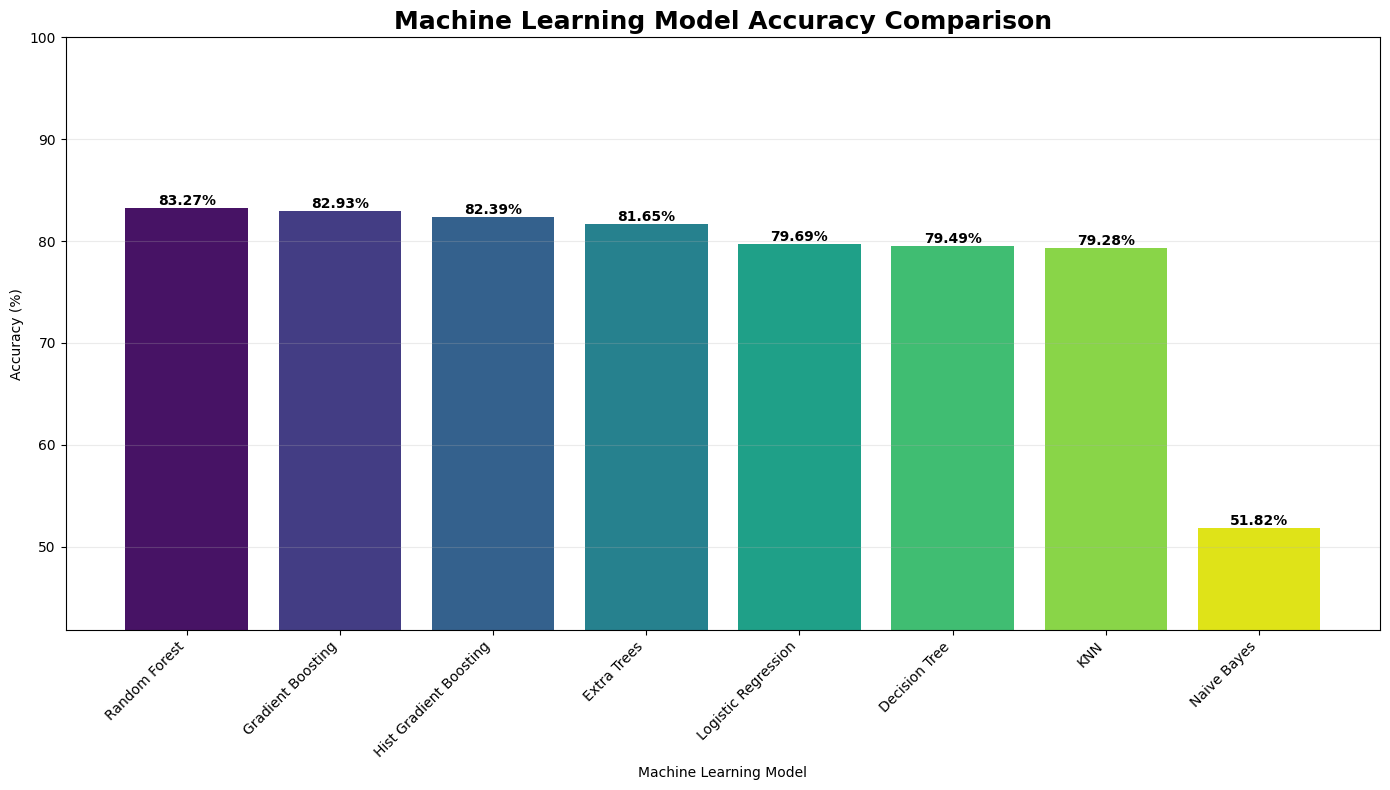

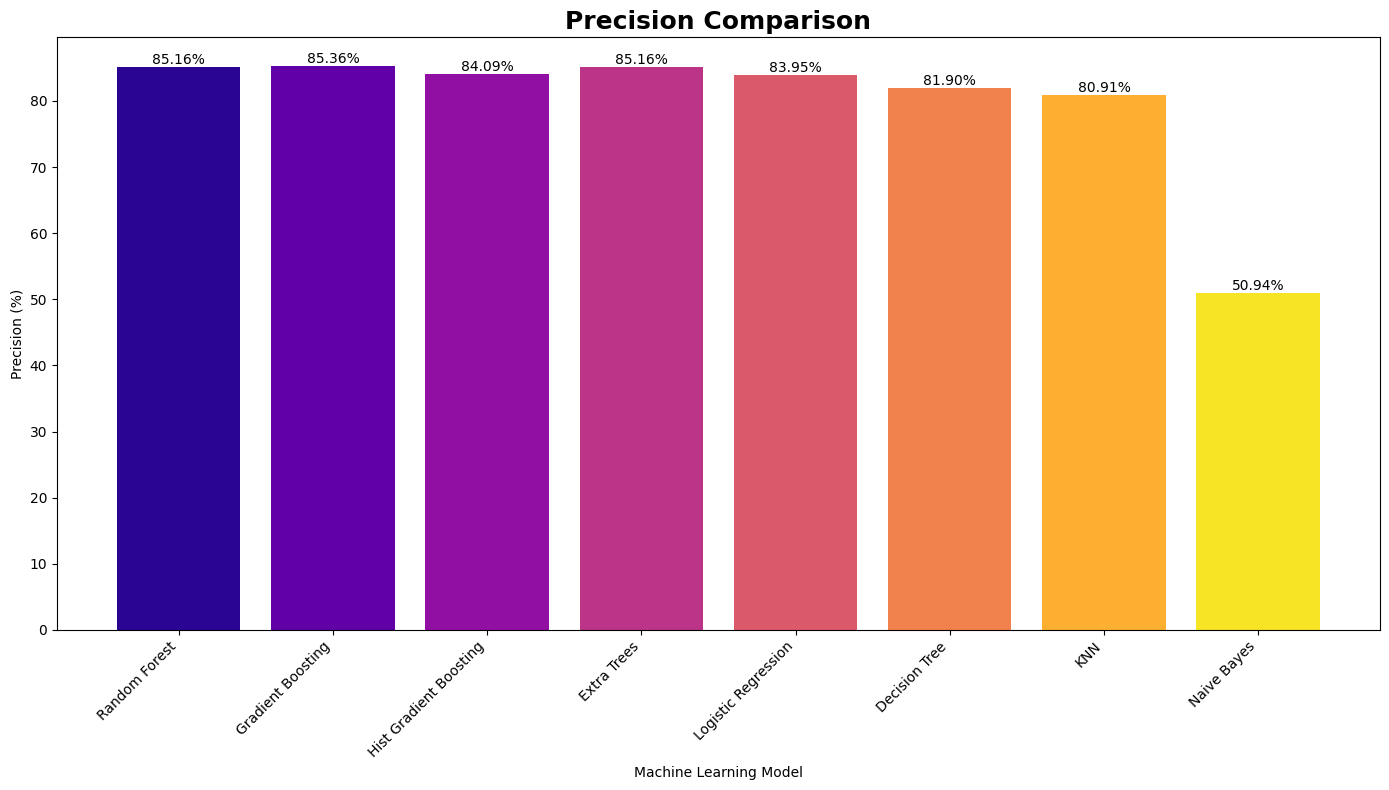

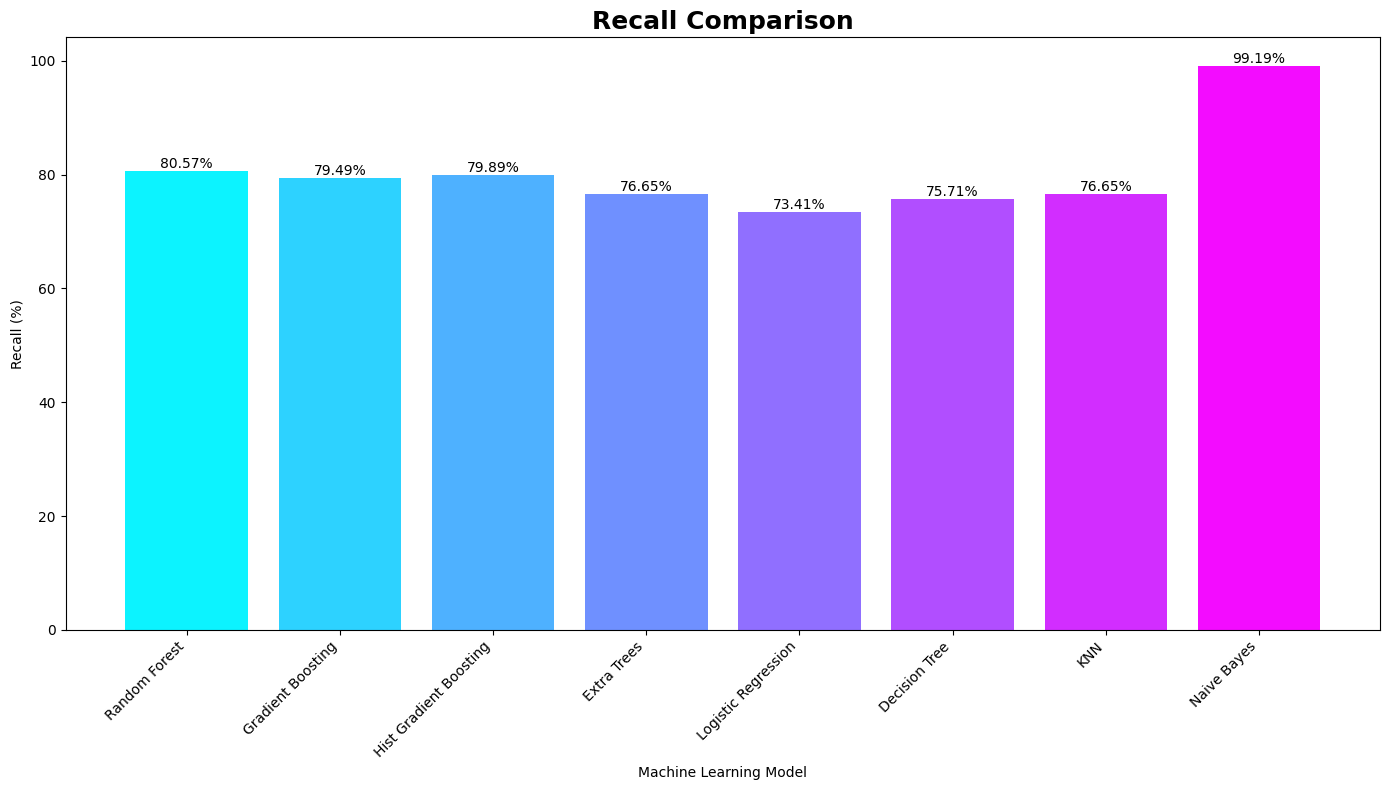

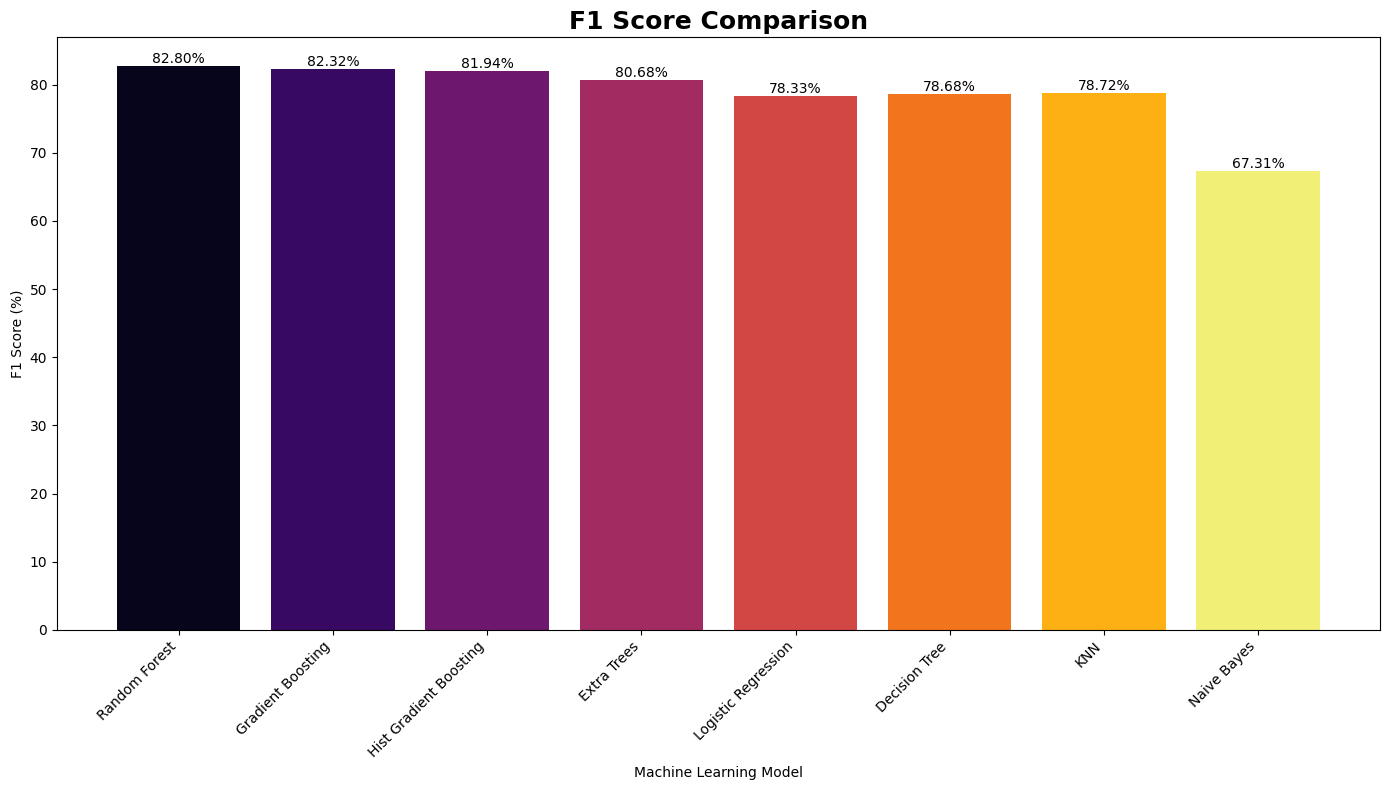

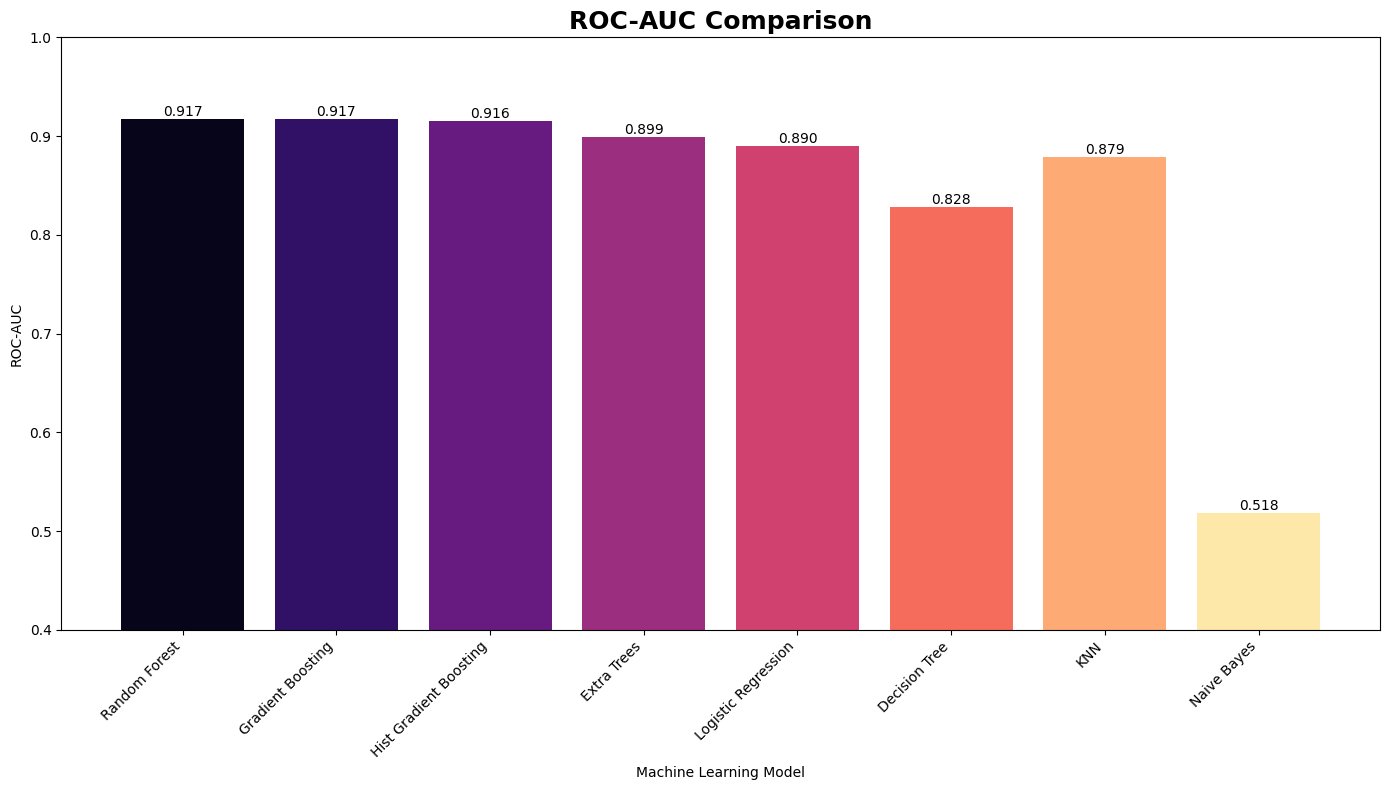

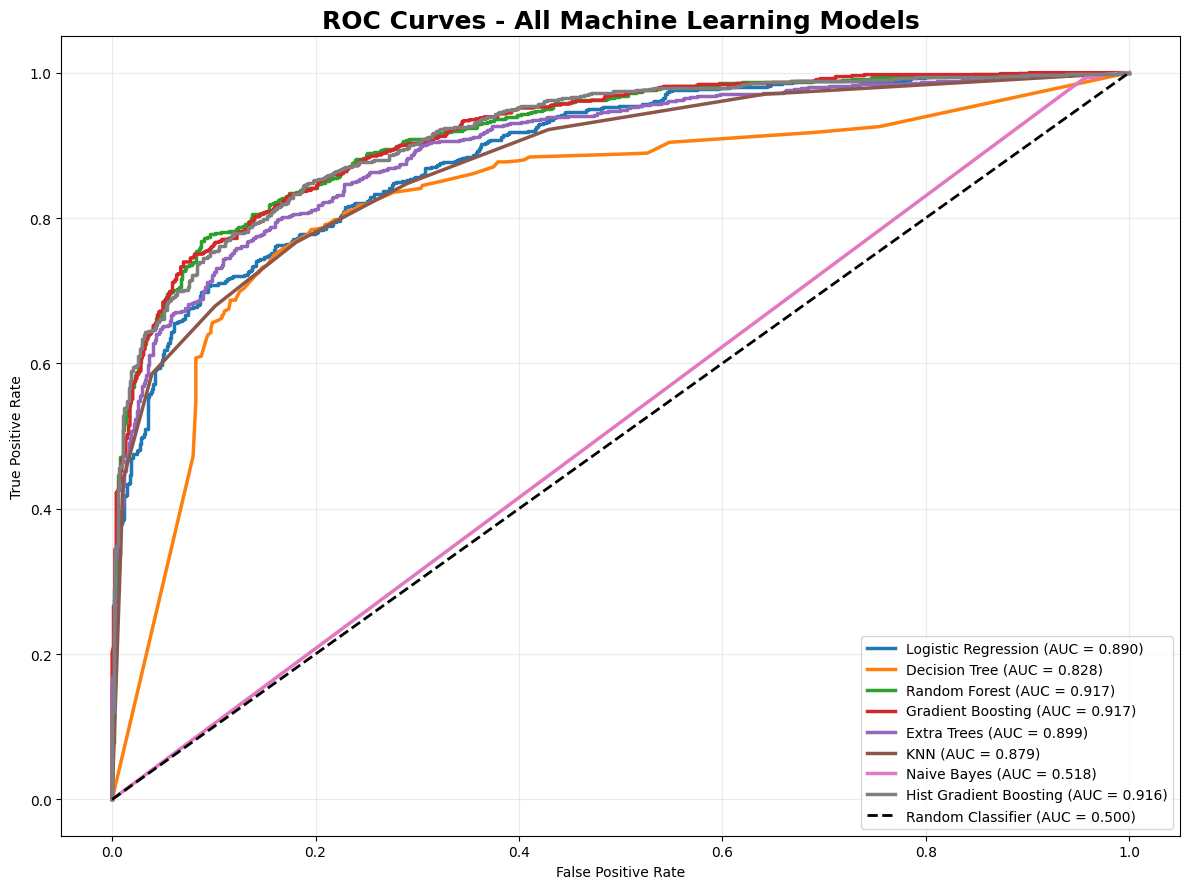


BEST MODEL
Best Model: Random Forest
Accuracy: 83.27%
Precision: 85.16%
Recall: 80.57%
F1 Score: 82.80%
ROC AUC: 0.9168


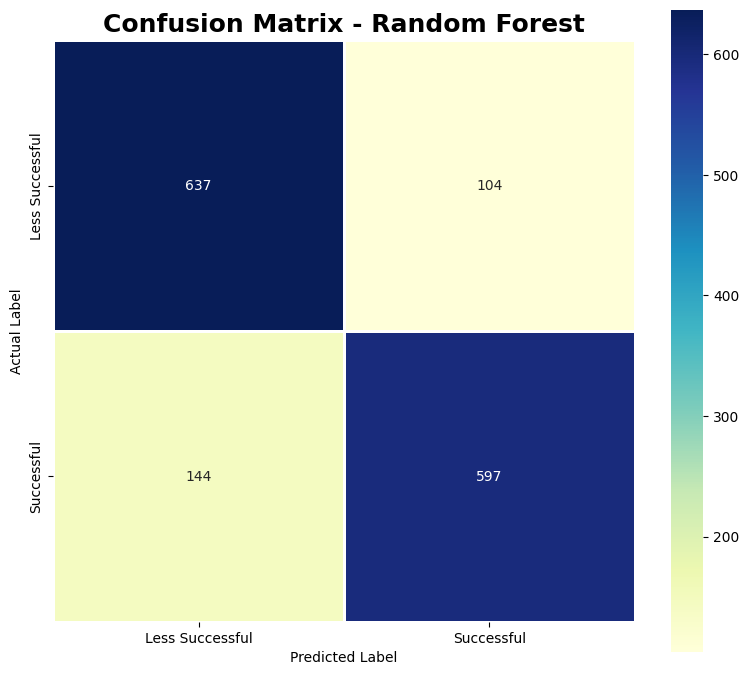


CLASSIFICATION REPORT - Random Forest
                 precision    recall  f1-score   support

Less Successful       0.82      0.86      0.84       741
     Successful       0.85      0.81      0.83       741

       accuracy                           0.83      1482
      macro avg       0.83      0.83      0.83      1482
   weighted avg       0.83      0.83      0.83      1482


TOP 20 FEATURE IMPORTANCES
                          Feature  Importance
              numeric__vote_count    0.290964
                  numeric__budget    0.261196
              numeric__popularity    0.175299
            numeric__release_year    0.090029
                 numeric__runtime    0.075359
            numeric__vote_average    0.064846
categorical__original_language_en    0.013395
categorical__original_language_fr    0.004477
categorical__original_language_ja    0.003865
categorical__original_language_it    0.002278
categorical__original_language_hi    0.002259
categorical__original_language_zh   

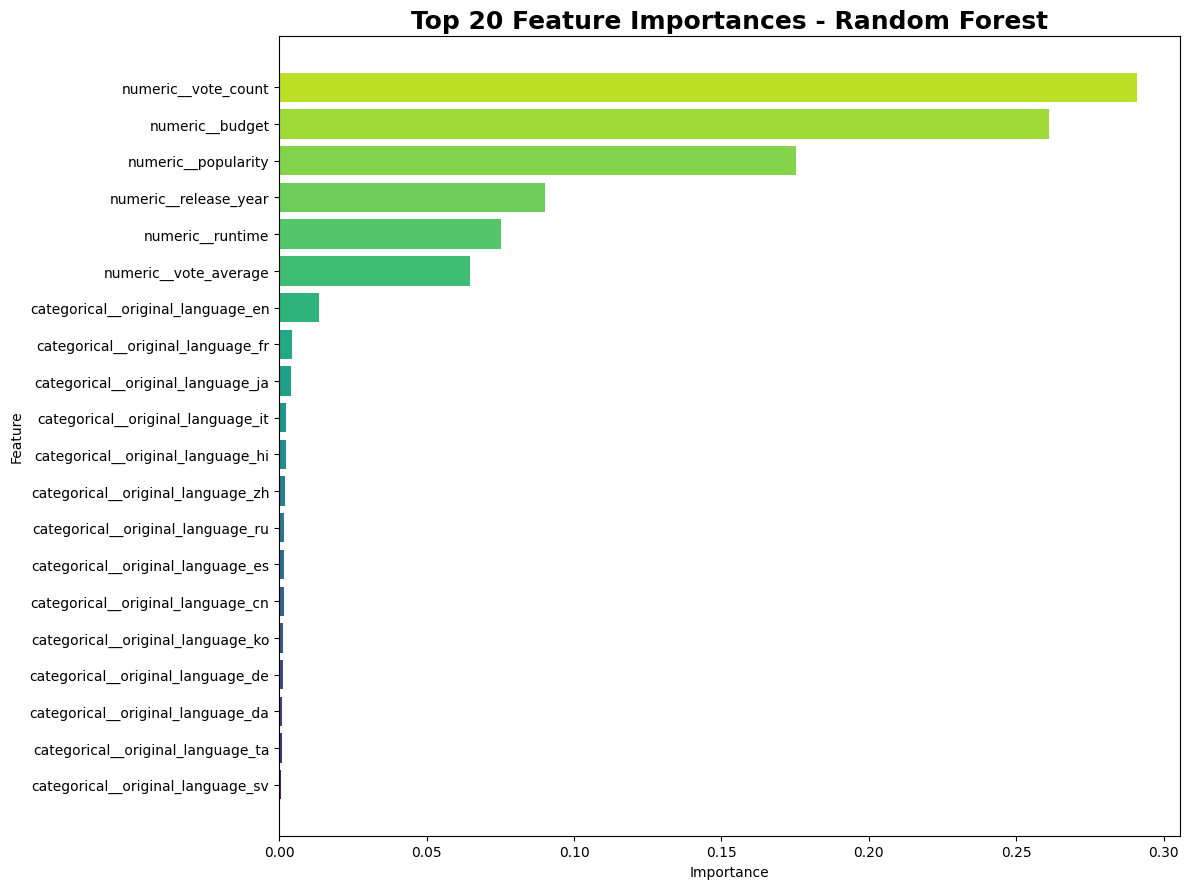


FINAL MODEL SUMMARY


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,Random Forest,83.27%,85.16%,80.57%,82.80%,0.9168
3,Gradient Boosting,82.93%,85.36%,79.49%,82.32%,0.9170
7,Hist Gradient Boosting,82.39%,84.09%,79.89%,81.94%,0.9158
4,Extra Trees,81.65%,85.16%,76.65%,80.68%,0.8989
0,Logistic Regression,79.69%,83.95%,73.41%,78.33%,0.8899
1,Decision Tree,79.49%,81.90%,75.71%,78.68%,0.8285
5,KNN,79.28%,80.91%,76.65%,78.72%,0.8790
6,Naive Bayes,51.82%,50.94%,99.19%,67.31%,0.5182


In [14]:

print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# 2. SELECT RELEVANT COLUMNS
# ============================================================

features = [
    "adult",
    "budget",
    "original_language",
    "popularity",
    "runtime",
    "status",
    "vote_average",
    "vote_count",
    "release_year"
]

available_features = [
    col for col in features
    if col in df.columns
]

print("\nFeatures used:")
print(available_features)


# ============================================================
# 3. PREPARE RELEASE YEAR
# ============================================================

if "release_year" not in df.columns:

    if "release_date" in df.columns:

        df["release_date"] = pd.to_datetime(
            df["release_date"],
            errors="coerce"
        )

        df["release_year"] = (
            df["release_date"]
            .dt.year
        )


# ============================================================
# 4. CONVERT NUMERIC COLUMNS
# ============================================================

numeric_columns = [
    "budget",
    "popularity",
    "runtime",
    "vote_average",
    "vote_count",
    "revenue",
    "release_year"
]

for col in numeric_columns:

    if col in df.columns:

        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )


# ============================================================
# 5. REMOVE INVALID REVENUE VALUES
# ============================================================

# Revenue is used to create our target.
# Movies with zero or missing revenue cannot be used
# for this particular target definition.

df_model = df[
    (df["revenue"] > 0)
].copy()

print("\nDataset after removing invalid revenue:")
print(df_model.shape)


# ============================================================
# 6. CREATE TARGET VARIABLE
# ============================================================

# Median revenue is calculated ONLY from usable movies.
#
# Successful movie = revenue >= median
# Less successful movie = revenue < median

revenue_median = df_model["revenue"].median()

df_model["success"] = (
    df_model["revenue"] >= revenue_median
).astype(int)

print("\nRevenue Median:")
print(revenue_median)

print("\nTarget Distribution:")
print(
    df_model["success"]
    .value_counts()
)


# ============================================================
# 7. CREATE X AND y
# ============================================================

available_features = [
    col for col in available_features
    if col in df_model.columns
]

X = df_model[available_features].copy()

y = df_model["success"].copy()


# ============================================================
# 8. HANDLE BOOLEAN / ADULT COLUMN
# ============================================================

if "adult" in X.columns:

    X["adult"] = (
        X["adult"]
        .astype(str)
        .str.lower()
        .map({
            "true": 1,
            "false": 0,
            "1": 1,
            "0": 0
        })
    )


# ============================================================
# 9. TRAIN-TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\n" + "=" * 80)
print("TRAIN-TEST SPLIT")
print("=" * 80)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


# ============================================================
# 10. IDENTIFY NUMERIC AND CATEGORICAL FEATURES
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline


numeric_features = X_train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


print("\nNumeric Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)


# ============================================================
# 11. NUMERIC PREPROCESSING
# ============================================================

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# ============================================================
# 12. CATEGORICAL PREPROCESSING
# ============================================================

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


# ============================================================
# 13. COLUMN TRANSFORMER
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ],
    remainder="drop"
)


# ============================================================
# 14. MACHINE LEARNING ALGORITHMS
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            max_depth=10,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            max_depth=15,
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=200,
            max_depth=15,
            random_state=42,
            n_jobs=-1
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=7
        ),

    "Naive Bayes":
        GaussianNB(),

    "Hist Gradient Boosting":
        HistGradientBoostingClassifier(
            max_iter=150,
            learning_rate=0.05,
            max_leaf_nodes=31,
            random_state=42
        )
}


# ============================================================
# 15. IMPORT EVALUATION METRICS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)


# ============================================================
# 16. TRAIN ALL MODELS
# ============================================================

results = []

trained_models = {}

roc_data = {}


for model_name, model in models.items():

    print("\n" + "=" * 80)
    print(model_name)
    print("=" * 80)

    # --------------------------------------------------------
    # CREATE PIPELINE
    # --------------------------------------------------------

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    pipeline.fit(
        X_train,
        y_train
    )

    # --------------------------------------------------------
    # PREDICTION
    # --------------------------------------------------------

    y_pred = pipeline.predict(
        X_test
    )

    # --------------------------------------------------------
    # PROBABILITY
    # --------------------------------------------------------

    if hasattr(
        pipeline.named_steps["model"],
        "predict_proba"
    ):

        y_probability = (
            pipeline
            .predict_proba(X_test)[:, 1]
        )

    else:

        y_probability = (
            pipeline
            .decision_function(X_test)
        )

    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    auc = roc_auc_score(
        y_test,
        y_probability
    )

    # --------------------------------------------------------
    # SAVE RESULTS
    # --------------------------------------------------------

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": auc
    })

    trained_models[
        model_name
    ] = pipeline

    # --------------------------------------------------------
    # ROC DATA
    # --------------------------------------------------------

    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_probability
    )

    roc_data[model_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": auc
    }

    # --------------------------------------------------------
    # PRINT METRICS
    # --------------------------------------------------------

    print(
        f"Accuracy : {accuracy * 100:.2f}%"
    )

    print(
        f"Precision: {precision * 100:.2f}%"
    )

    print(
        f"Recall   : {recall * 100:.2f}%"
    )

    print(
        f"F1 Score : {f1 * 100:.2f}%"
    )

    print(
        f"ROC AUC  : {auc:.4f}"
    )

    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "Less Successful",
                "Successful"
            ],
            zero_division=0
        )
    )


# ============================================================
# 17. MODEL COMPARISON TABLE
# ============================================================

results_df = pd.DataFrame(
    results
).sort_values(
    by="Accuracy",
    ascending=False
)

print("\n" + "=" * 80)
print("MODEL COMPARISON")
print("=" * 80)

print(
    results_df.to_string(
        index=False
    )
)


# ============================================================
# 18. ACCURACY COMPARISON
# ============================================================

plt.figure(figsize=(14, 8))

bars = plt.bar(
    results_df["Model"],
    results_df["Accuracy"] * 100,
    color=plt.cm.viridis(
        np.linspace(
            0.05,
            0.95,
            len(results_df)
        )
    )
)

plt.title(
    "Machine Learning Model Accuracy Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.ylim(
    max(
        0,
        results_df["Accuracy"].min() * 100 - 10
    ),
    100
)

for bar, value in zip(
    bars,
    results_df["Accuracy"] * 100
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()


# ============================================================
# 19. PRECISION COMPARISON
# ============================================================

plt.figure(figsize=(14, 8))

bars = plt.bar(
    results_df["Model"],
    results_df["Precision"] * 100,
    color=plt.cm.plasma(
        np.linspace(
            0.05,
            0.95,
            len(results_df)
        )
    )
)

plt.title(
    "Precision Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Precision (%)")

plt.xticks(
    rotation=45,
    ha="right"
)

for bar, value in zip(
    bars,
    results_df["Precision"] * 100
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 20. RECALL COMPARISON
# ============================================================

plt.figure(figsize=(14, 8))

bars = plt.bar(
    results_df["Model"],
    results_df["Recall"] * 100,
    color=plt.cm.cool(
        np.linspace(
            0.05,
            0.95,
            len(results_df)
        )
    )
)

plt.title(
    "Recall Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Recall (%)")

plt.xticks(
    rotation=45,
    ha="right"
)

for bar, value in zip(
    bars,
    results_df["Recall"] * 100
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 21. F1 SCORE COMPARISON
# ============================================================

plt.figure(figsize=(14, 8))

bars = plt.bar(
    results_df["Model"],
    results_df["F1 Score"] * 100,
    color=plt.cm.inferno(
        np.linspace(
            0.05,
            0.95,
            len(results_df)
        )
    )
)

plt.title(
    "F1 Score Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Machine Learning Model")
plt.ylabel("F1 Score (%)")

plt.xticks(
    rotation=45,
    ha="right"
)

for bar, value in zip(
    bars,
    results_df["F1 Score"] * 100
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 22. ROC AUC COMPARISON
# ============================================================

plt.figure(figsize=(14, 8))

bars = plt.bar(
    results_df["Model"],
    results_df["ROC AUC"],
    color=plt.cm.magma(
        np.linspace(
            0.05,
            0.95,
            len(results_df)
        )
    )
)

plt.title(
    "ROC-AUC Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Machine Learning Model")
plt.ylabel("ROC-AUC")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.ylim(
    0.4,
    1.0
)

for bar, value in zip(
    bars,
    results_df["ROC AUC"]
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 23. ROC CURVES - ALL MODELS
# ============================================================

plt.figure(figsize=(12, 9))

for model_name, data in roc_data.items():

    plt.plot(
        data["fpr"],
        data["tpr"],
        linewidth=2.5,
        label=(
            f"{model_name} "
            f"(AUC = {data['auc']:.3f})"
        )
    )


# Random classifier

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    color="black",
    label="Random Classifier (AUC = 0.500)"
)


plt.title(
    "ROC Curves - All Machine Learning Models",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.legend(
    loc="lower right"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()


# ============================================================
# 24. FIND BEST MODEL
# ============================================================

best_model_name = (
    results_df
    .iloc[0]["Model"]
)

best_model = (
    trained_models[
        best_model_name
    ]
)

print("\n" + "=" * 80)
print("BEST MODEL")
print("=" * 80)

print(
    "Best Model:",
    best_model_name
)

print(
    "Accuracy:",
    f"{results_df.iloc[0]['Accuracy'] * 100:.2f}%"
)

print(
    "Precision:",
    f"{results_df.iloc[0]['Precision'] * 100:.2f}%"
)

print(
    "Recall:",
    f"{results_df.iloc[0]['Recall'] * 100:.2f}%"
)

print(
    "F1 Score:",
    f"{results_df.iloc[0]['F1 Score'] * 100:.2f}%"
)

print(
    "ROC AUC:",
    f"{results_df.iloc[0]['ROC AUC']:.4f}"
)


# ============================================================
# 25. CONFUSION MATRIX FOR BEST MODEL
# ============================================================

best_predictions = (
    best_model.predict(
        X_test
    )
)

cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(8, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    linewidths=1,
    square=True,
    xticklabels=[
        "Less Successful",
        "Successful"
    ],
    yticklabels=[
        "Less Successful",
        "Successful"
    ]
)

plt.title(
    f"Confusion Matrix - {best_model_name}",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.tight_layout()
plt.show()


# ============================================================
# 26. CLASSIFICATION REPORT FOR BEST MODEL
# ============================================================

print("\n" + "=" * 80)
print(
    f"CLASSIFICATION REPORT - {best_model_name}"
)
print("=" * 80)

print(
    classification_report(
        y_test,
        best_predictions,
        target_names=[
            "Less Successful",
            "Successful"
        ],
        zero_division=0
    )
)


# ============================================================
# 27. FEATURE IMPORTANCE
# ============================================================

# Feature importance is available for tree-based models.

tree_model_names = [
    "Decision Tree",
    "Random Forest",
    "Gradient Boosting",
    "Extra Trees",
    "Hist Gradient Boosting"
]

if best_model_name in tree_model_names:

    model_object = (
        best_model.named_steps["model"]
    )

    # Get transformed feature names

    transformed_names = (
        best_model
        .named_steps["preprocessor"]
        .get_feature_names_out()
    )

    # HistGradientBoosting also supports feature_importances_
    # only in some versions, so check first.

    if hasattr(
        model_object,
        "feature_importances_"
    ):

        importances = (
            model_object
            .feature_importances_
        )

        feature_importance_df = pd.DataFrame({
            "Feature": transformed_names,
            "Importance": importances
        })

        feature_importance_df = (
            feature_importance_df
            .sort_values(
                "Importance",
                ascending=False
            )
            .head(20)
        )

        print("\n" + "=" * 80)
        print("TOP 20 FEATURE IMPORTANCES")
        print("=" * 80)

        print(
            feature_importance_df.to_string(
                index=False
            )
        )

        plt.figure(figsize=(12, 9))

        bars = plt.barh(
            feature_importance_df["Feature"][::-1],
            feature_importance_df["Importance"][::-1],
            color=plt.cm.viridis(
                np.linspace(
                    0.1,
                    0.9,
                    len(feature_importance_df)
                )
            )
        )

        plt.title(
            f"Top 20 Feature Importances - {best_model_name}",
            fontsize=18,
            fontweight="bold"
        )

        plt.xlabel(
            "Importance"
        )

        plt.ylabel(
            "Feature"
        )

        plt.tight_layout()
        plt.show()


# ============================================================
# 28. FINAL MODEL SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("FINAL MODEL SUMMARY")
print("=" * 80)

display(
    results_df.style
    .format({
        "Accuracy": "{:.2%}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1 Score": "{:.2%}",
        "ROC AUC": "{:.4f}"
    })
)

## thank you..pls upvote!!!!!!!!